# 🛡️ Outliers en Datos Aseguradores
## Frecuencia · Severidad · Transformaciones Estabilizadoras

---

Este notebook integra dos módulos en una sola guía de estudio:

| Módulo | Contenido |
|---|---|
| **Módulo A — Detección y Tratamiento** | Métodos IQR, Z-Score, Z-Score Modificado, Winsorización |
| **Módulo B — Transformaciones Estabilizadoras** | Raíz cuadrada, arcoseno de raíz cuadrada, arcoseno hiperbólico |

Cada ejemplo didáctico primero detecta y trata los outliers en escala original,
y luego aplica la transformación apropiada para mejorar la detección y el modelado.

## Índice

1. [Conceptos y métodos de detección](#seccion-1)
2. [Marco teórico de transformaciones](#seccion-2)
3. [Ejemplo 1 — Seguro de Automóvil (Severidad)](#ejemplo-1)
4. [Ejemplo 2 — Seguro de Salud (Frecuencia)](#ejemplo-2)
5. [Ejemplo 3 — Dataset Público insurance.csv](#ejemplo-3)
6. [Ejercicios integradores](#ejercicios)
7. [Resumen y conclusiones](#resumen)

---

<a id='seccion-1'></a>
# Módulo A — Detección y Tratamiento de Outliers

## ¿Por qué importan los outliers en seguros?

En el mundo actuarial, un solo siniestro catastrófico puede distorsionar completamente
la estimación de la **prima pura**, los modelos de **reservas** o las proyecciones de
**pérdida esperada**.

| Componente | ¿Qué modela? | Riesgo de outliers |
|---|---|---|
| **Frecuencia** | Número de siniestros por póliza/período | Valores extremos en eventos catastróficos |
| **Severidad** | Monto de pérdida por siniestro | Siniestros de alta cuantía sesgan la media |
| **Prima Pura** | Frecuencia × Severidad | Doble impacto si ambos tienen outliers |

### Tipos de distribución en seguros

- **Frecuencia**: Poisson (eventos independientes) o Binomial Negativa (sobredispersión)
- **Severidad**: Log-Normal (autos, salud), Pareto/Gamma/Weibull (catastróficos)

---

---
## 🔍 Métodos de Detección de Outliers

Antes de los ejemplos, revisemos los métodos principales que usaremos:

### 1. Método IQR (Rango Intercuartílico)
$$\text{Límite superior} = Q_3 + 1.5 \times IQR$$
$$\text{Límite inferior} = Q_1 - 1.5 \times IQR$$
- **Ventaja**: Robusto a la distribución subyacente
- **Uso en seguros**: Bueno para severidades simétricas (daños de auto leve)

### 2. Z-Score
$$z_i = \frac{x_i - \bar{x}}{s}$$
- Valores con $|z| > 3$ se consideran outliers
- **Cuidado**: Sensible a la misma presencia de outliers; usar con cautela en seguros

### 3. Z-Score Modificado (Basado en Mediana)
$$M_i = \frac{0.6745 \cdot (x_i - \tilde{x})}{MAD}$$
donde $MAD = \text{mediana}(|x_i - \tilde{x}|)$
- **Ventaja**: Mucho más robusto que el Z-Score clásico
- **Uso en seguros**: Ideal para severidades con cola pesada

### 4. Percentil / Límite de Política (Winsorización)
- Truncar o acotar valores en percentiles específicos (ej. p99)
- Técnica estándar en actuaría: **"limitar" o "capping"** de siniestros

### 5. Criterio de Grubbs
- Prueba estadística formal para un outlier a la vez
- Útil cuando se necesita evidencia estadística formal

In [2]:
# ============================================================
# SETUP — Importaciones y funciones base
# (Integra ambos notebooks: detección + transformaciones)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, lognorm, iqr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
np.random.seed(42)

# ── Detección de outliers ──────────────────────────────────────

def detectar_outliers_iqr(serie, factor=1.5):
    """Detección por Rango Intercuartílico."""
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    li, ls = Q1 - factor*IQR, Q3 + factor*IQR
    return serie < li, serie > ls, li, ls

def detectar_outliers_zscore(serie, umbral=3):
    """Detección por Z-Score clásico."""
    return np.abs(stats.zscore(serie)) > umbral

def detectar_outliers_zscore_mod(serie, umbral=3.5):
    """Detección por Z-Score Modificado (robusto a outliers)."""
    mediana = serie.median()
    MAD = np.median(np.abs(serie - mediana))
    if MAD == 0:
        return pd.Series([False]*len(serie), index=serie.index)
    return 0.6745 * np.abs(serie - mediana) / MAD > umbral

def resumen_outliers(serie, nombre='Variable'):
    """Reporte comparativo de todos los métodos de detección."""
    _, out_iqr, li, ls = detectar_outliers_iqr(serie)
    out_z  = detectar_outliers_zscore(serie)
    out_zm = detectar_outliers_zscore_mod(serie)
    p99    = serie.quantile(0.99)
    print(f"\n{'='*55}")
    print(f"  📊 Resumen de Outliers: {nombre}")
    print(f"{'='*55}")
    print(f"  N total          : {len(serie):,}")
    print(f"  Media            : {serie.mean():,.2f}")
    print(f"  Mediana          : {serie.median():,.2f}")
    print(f"  Desv. Estándar   : {serie.std():,.2f}")
    print(f"  Mín / Máx        : {serie.min():,.2f} / {serie.max():,.2f}")
    print(f"  Percentil 99     : {p99:,.2f}")
    print(f"  Asimetría (skew) : {serie.skew():.3f}")
    print(f"  Curtosis         : {serie.kurtosis():.3f}")
    print(f"\n  --- Outliers detectados ---")
    print(f"  IQR (×1.5)       : {out_iqr.sum():,} ({out_iqr.mean()*100:.1f}%)  [>{ls:,.0f}]")
    print(f"  Z-Score (|z|>3)  : {out_z.sum():,} ({out_z.mean()*100:.1f}%)")
    print(f"  Z-Score Mod.     : {out_zm.sum():,} ({out_zm.mean()*100:.1f}%)")
    print(f"  Capping p99      : {(serie>p99).sum():,} ({(serie>p99).mean()*100:.1f}%)")
    print(f"{'='*55}")
    return {'iqr':out_iqr,'zscore':out_z,'zscore_mod':out_zm,
            'p99':serie>p99,'lim_sup_iqr':ls,'p99_val':p99}

def winsorizar(serie, p_inf=0.0, p_sup=0.99):
    """Winsorización entre percentiles."""
    return serie.clip(lower=serie.quantile(p_inf), upper=serie.quantile(p_sup))

# ── Transformaciones estabilizadoras ──────────────────────────

def t_sqrt(x):
    """Raíz cuadrada. x >= 0."""
    return np.sqrt(np.maximum(x, 0))

def t_arcsin_sqrt(p):
    """Arcoseno de raíz cuadrada. p en [0,1]."""
    return np.arcsin(np.sqrt(np.clip(p, 0, 1)))

def t_arcsinh(x, escala=1.0):
    """Arcoseno hiperbólico escalado. Funciona en x=0."""
    return np.arcsinh(x / escala)

def qqplot_ax(ax, data, titulo, color='#4C9BE8'):
    """QQ-plot Normal sobre un eje dado."""
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.5, s=18, edgecolors='none')
    xl = np.array([min(osm), max(osm)])
    ax.plot(xl, slope*xl+intercept, 'r-', lw=2, label=f'R²={r**2:.3f}')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')

print('✅ Setup completo — funciones de detección y transformación listas')

✅ Setup completo — funciones de detección y transformación listas


---
<a id='seccion-2'></a>
# Módulo B — Transformaciones Estabilizadoras

Las distribuciones de seguros tienen **colas pesadas**: la varianza crece con la media
(heterocedasticidad). Transformar los datos antes de buscar outliers produce:

1. Detección **más precisa** — menos falsos positivos en la cola
2. Residuos de modelos más **normales**
3. Comparación entre pólizas de distinto tamaño más **justa**

| Transformación | Fórmula | Ideal para | Estabiliza |
|---|---|---|---|
| **Raíz Cuadrada** | $y = \sqrt{x}$ | Frecuencias (conteos) | $\text{Var} \propto \mu$ (Poisson) |
| **Arcoseno de Raíz Cuadrada** | $y = \arcsin(\sqrt{p})$ | Tasas $p \in [0,1]$ | $\text{Var} \propto p(1-p)$ (Binomial) |
| **Arcoseno Hiperbólico** | $y = \text{arcsinh}(x/c) = \ln(x/c + \sqrt{(x/c)^2+1})$ | Severidades con ceros | $\text{Var} \propto \mu^2$ (log-normal) |

---

## 📐 Marco Teórico de las Transformaciones

### 1. Transformación Raíz Cuadrada — $\sqrt{x}$

**Fundamento**: Si $X \sim \text{Poisson}(\lambda)$, entonces $\text{Var}(X) = \lambda = E[X]$.
La varianza **crece con la media**, lo que distorsiona el Z-Score.
Aplicando $Y = \sqrt{X}$, por el método delta:

$$\text{Var}(\sqrt{X}) \approx \left(\frac{1}{2\sqrt{\lambda}}\right)^2 \cdot \lambda = \frac{1}{4}$$

La varianza se vuelve **constante (≈ 1/4)**, independiente de $\lambda$.

> ✅ **Úsala cuando**: modelas número de siniestros por póliza/período (datos de conteo).

---

### 2. Transformación Arcoseno de Raíz Cuadrada — $\arcsin(\sqrt{p})$

**Fundamento**: Si $P = X/n$ es una proporción binomial, $\text{Var}(P) = p(1-p)/n$.
La varianza depende del valor de $p$. Aplicando la transformación de Freeman-Tukey:

$$Y = \arcsin\!\left(\sqrt{P}\right)$$

$$\text{Var}(Y) \approx \frac{1}{4n} \quad \text{(constante)}$$

> ✅ **Úsala cuando**: trabajas con **tasas de siniestralidad** $= \text{Siniestros}/\text{Expuestos}$,
> frecuencias relativas o porcentajes de siniestros por ramo. El rango de entrada es $[0, 1]$.

**Nota**: La salida está en radianes ∈ $[0, \pi/2]$.

---

### 3. Arcoseno Hiperbólico — $\text{arcsinh}(x)$

**Fundamento**: Es una generalización del logaritmo que funciona también para $x = 0$ o $x < 0$:

$$\text{arcsinh}(x) = \ln\!\left(x + \sqrt{x^2 + 1}\right)$$

Para valores grandes: $\text{arcsinh}(x) \approx \ln(2x)$, comportamiento similar a $\log$.
Para valores pequeños: $\text{arcsinh}(x) \approx x$ (no explota en cero).

> ✅ **Úsala cuando**: la severidad incluye **ceros o valores muy pequeños** (seguros con
> franquicia, siniestros nulos), o cuando necesitas las propiedades del log pero sin
> restricción de dominio positivo.

---

### Comparación visual de las tres transformaciones

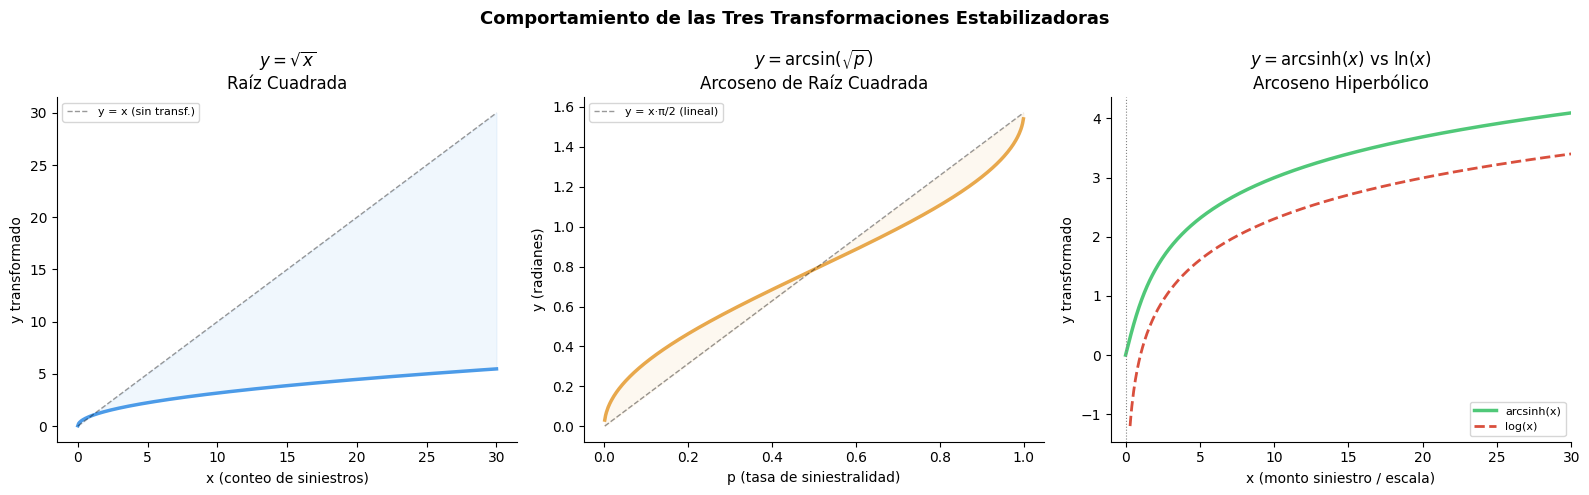

💡 Nota clave:
   - √x comprime valores grandes pero crece más lento que log
   - arcsin(√p) "abre" los extremos (cerca de 0 y 1) para mayor sensibilidad
   - arcsinh ≈ log para x grande, pero funciona en x=0 (a diferencia del log)


In [3]:
# ============================================================
# VISUALIZACIÓN COMPARATIVA DE LAS TRES TRANSFORMACIONES
# ============================================================
x_cont = np.linspace(0.001, 30, 500)
p_cont = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comportamiento de las Tres Transformaciones Estabilizadoras',
             fontsize=13, fontweight='bold')

# Raíz cuadrada
axes[0].plot(x_cont, np.sqrt(x_cont), color='#4C9BE8', lw=2.5)
axes[0].plot(x_cont, x_cont, 'k--', lw=1, alpha=0.4, label='y = x (sin transf.)')
axes[0].set_title('$y = \\sqrt{x}$\nRaíz Cuadrada')
axes[0].set_xlabel('x (conteo de siniestros)')
axes[0].set_ylabel('y transformado')
axes[0].legend(fontsize=8)
axes[0].fill_between(x_cont, np.sqrt(x_cont), x_cont, alpha=0.08, color='#4C9BE8')

# Arcoseno de raíz cuadrada
axes[1].plot(p_cont, np.arcsin(np.sqrt(p_cont)), color='#E8A84C', lw=2.5)
axes[1].plot(p_cont, p_cont * np.pi/2, 'k--', lw=1, alpha=0.4, label='y = x·π/2 (lineal)')
axes[1].set_title('$y = \\arcsin(\\sqrt{p})$\nArcoseno de Raíz Cuadrada')
axes[1].set_xlabel('p (tasa de siniestralidad)')
axes[1].set_ylabel('y (radianes)')
axes[1].legend(fontsize=8)
axes[1].fill_between(p_cont, np.arcsin(np.sqrt(p_cont)), p_cont*np.pi/2, alpha=0.08, color='#E8A84C')

# Arcoseno hiperbólico vs log
axes[2].plot(x_cont, np.arcsinh(x_cont), color='#50C878', lw=2.5, label='arcsinh(x)')
axes[2].plot(x_cont[5:], np.log(x_cont[5:]), color='#D94F3D', lw=2, ls='--', label='log(x)')
axes[2].axvline(0, color='gray', lw=0.8, ls=':')
axes[2].set_title('$y = \\text{arcsinh}(x)$ vs $\\ln(x)$\nArcoseno Hiperbólico')
axes[2].set_xlabel('x (monto siniestro / escala)')
axes[2].set_ylabel('y transformado')
axes[2].legend(fontsize=8)
axes[2].set_xlim(-1, 30)

plt.tight_layout()
plt.show()

print('💡 Nota clave:')
print('   - √x comprime valores grandes pero crece más lento que log')
print('   - arcsin(√p) "abre" los extremos (cerca de 0 y 1) para mayor sensibilidad')
print('   - arcsinh ≈ log para x grande, pero funciona en x=0 (a diferencia del log)')

---
<a id='ejemplo-1'></a>
# 📌 Ejemplo 1 — Seguro de Automóvil: Severidad

## Contexto

Portafolio de **200 siniestros** de automóvil. La mayoría corresponde a colisiones
menores (Log-Normal), pero un 4.5% son siniestros catastróficos (vehículos de lujo,
accidentes múltiples).

### Plan de análisis

| Paso | Acción | Herramienta |
|---|---|---|
| 1 | Detección en escala original | IQR, Z-Score Mod. |
| 2 | Tratamiento | Winsorización p99 |
| 3 | Transformación estabilizadora | `arcsinh(x/mediana)` |
| 4 | Re-detección en escala transformada | IQR en arcsinh |
| 5 | Comparativa | QQ-plots, asimetría, outliers detectados |

> **¿Por qué arcsinh?** La severidad puede incluir ceros (siniestros rechazados);
> arcsinh funciona en $x=0$ y se comporta como $\log$ para valores grandes.

---

In [4]:
# ============================================================
# EJEMPLO 1: Generación de datos — Severidad Automotriz
# ============================================================

np.random.seed(42)
n_total = 200

# Siniestros "normales" — distribución Log-Normal
n_normales = 191
siniestros_normales = np.random.lognormal(mean=8.5, sigma=0.8, size=n_normales)

# Siniestros "catastróficos" — valores extremos (accidentes graves, vehículos de lujo)
siniestros_cat = np.array([185_000, 210_000, 320_000, 145_000, 275_000,
                            195_000, 410_000, 165_000, 380_000])

# Combinar
severidad_auto = pd.Series(
    np.concatenate([siniestros_normales, siniestros_cat]),
    name='Monto_Siniestro_MXN'
).round(2)

# Mezclar orden
severidad_auto = severidad_auto.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total de siniestros: {len(severidad_auto)}')
print(f'Siniestros normales: {n_normales}')
print(f'Siniestros catastróficos: {len(siniestros_cat)}')
print('\nPrimeros 5 registros:')
print(severidad_auto.head())

Total de siniestros: 200
Siniestros normales: 191
Siniestros catastróficos: 9

Primeros 5 registros:
0    1524.14
1    3134.33
2    3037.03
3    1894.97
4    5322.62
Name: Monto_Siniestro_MXN, dtype: float64


In [5]:
# ============================================================
# EJEMPLO 1: Detección de Outliers en Severidad
# ============================================================

resultados_e1 = resumen_outliers(severidad_auto, 'Monto Siniestro Automotriz (MXN)')


  📊 Resumen de Outliers: Monto Siniestro Automotriz (MXN)
  N total          : 200
  Media            : 17,525.53
  Mediana          : 5,172.48
  Desv. Estándar   : 55,268.12
  Mín / Máx        : 604.38 / 410,000.00
  Percentil 99     : 320,600.00
  Asimetría (skew) : 5.266
  Curtosis         : 28.953

  --- Outliers detectados ---
  IQR (×1.5)       : 20 (10.0%)  [>16,647]
  Z-Score (|z|>3)  : 7 (3.5%)
  Z-Score Mod.     : 16 (8.0%)
  Capping p99      : 2 (1.0%)


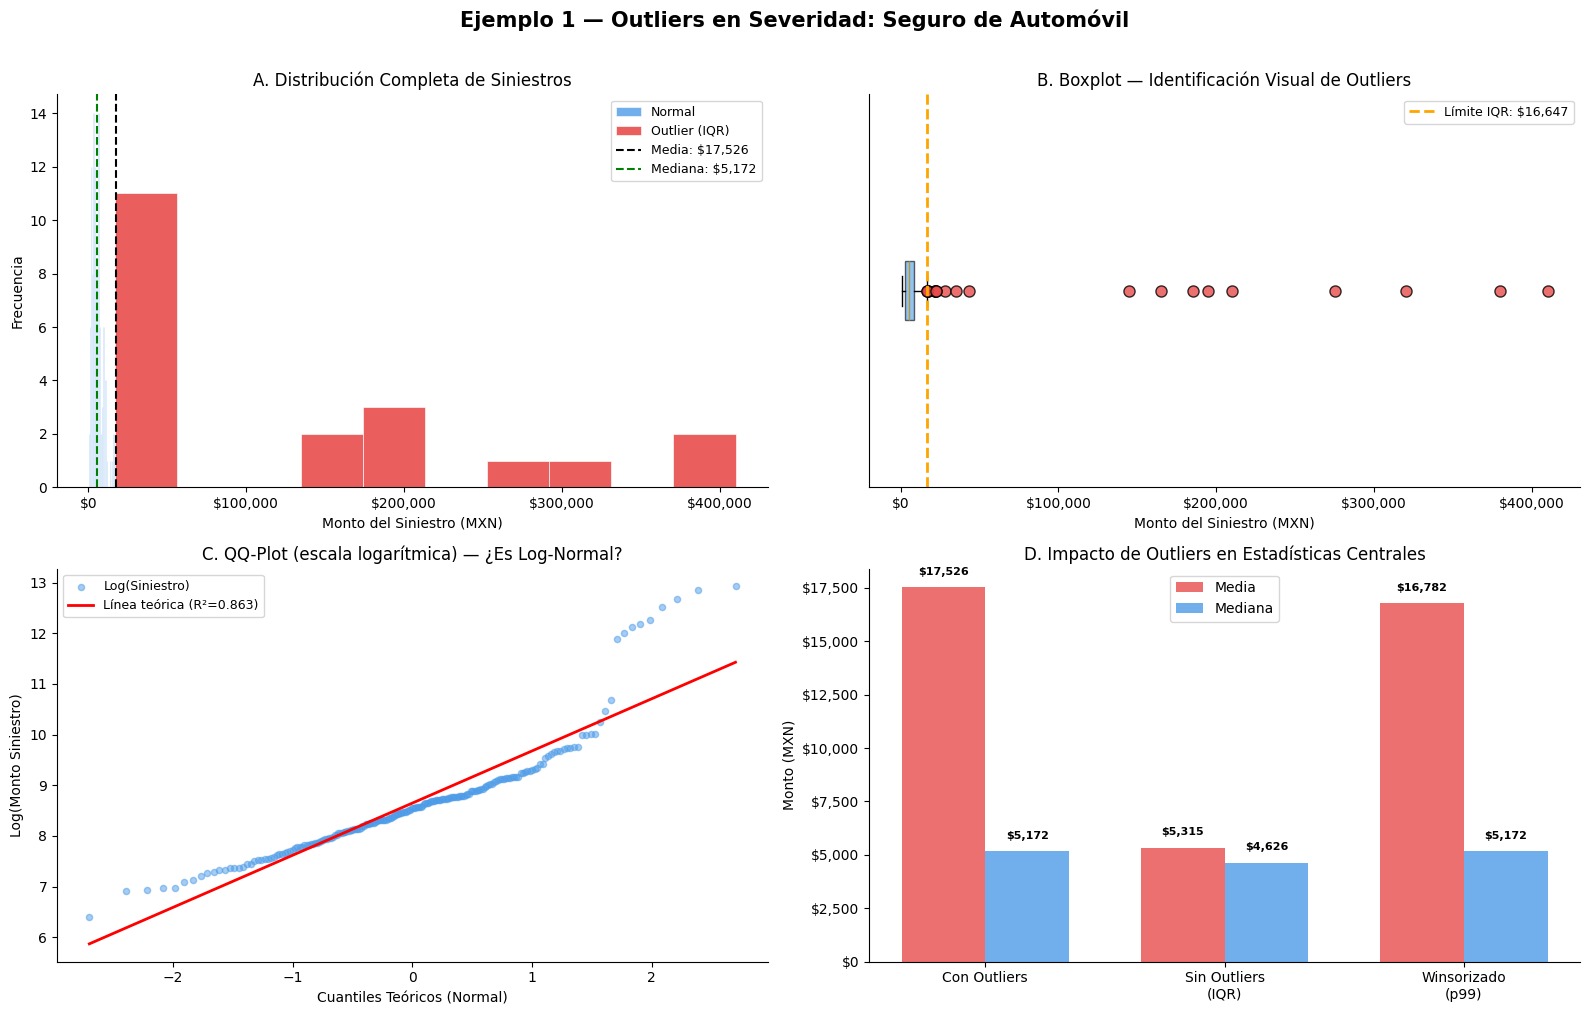

✅ Gráfica guardada como ejemplo1_severidad_auto.png


In [6]:
# ============================================================
# EJEMPLO 1: Visualización
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Ejemplo 1 — Outliers en Severidad: Seguro de Automóvil',
             fontsize=15, fontweight='bold', y=1.01)

colores = {'normal': '#4C9BE8', 'outlier': '#E84C4C'}

# --- Panel A: Histograma completo ---
ax = axes[0, 0]
mask_out = resultados_e1['iqr']
ax.hist(severidad_auto[~mask_out], bins=40, color=colores['normal'],
        alpha=0.8, label='Normal', edgecolor='white', linewidth=0.5)
ax.hist(severidad_auto[mask_out], bins=10, color=colores['outlier'],
        alpha=0.9, label='Outlier (IQR)', edgecolor='white', linewidth=0.5)
ax.axvline(severidad_auto.mean(), color='black', ls='--', lw=1.5, label=f'Media: ${severidad_auto.mean():,.0f}')
ax.axvline(severidad_auto.median(), color='green', ls='--', lw=1.5, label=f'Mediana: ${severidad_auto.median():,.0f}')
ax.set_title('A. Distribución Completa de Siniestros')
ax.set_xlabel('Monto del Siniestro (MXN)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# --- Panel B: Boxplot con outliers marcados ---
ax = axes[0, 1]
bp = ax.boxplot(severidad_auto, vert=False, patch_artist=True,
                flierprops=dict(marker='o', markerfacecolor=colores['outlier'],
                                markersize=8, alpha=0.8))
bp['boxes'][0].set_facecolor(colores['normal'])
bp['boxes'][0].set_alpha(0.6)
ax.set_title('B. Boxplot — Identificación Visual de Outliers')
ax.set_xlabel('Monto del Siniestro (MXN)')
ax.set_yticks([])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Anotar límite IQR
lim_sup = resultados_e1['lim_sup_iqr']
ax.axvline(lim_sup, color='orange', ls='--', lw=2, label=f'Límite IQR: ${lim_sup:,.0f}')
ax.legend(fontsize=9)

# --- Panel C: QQ-Plot para verificar distribución Log-Normal ---
ax = axes[1, 0]
log_data = np.log(severidad_auto)
(osm, osr), (slope, intercept, r) = stats.probplot(log_data, dist='norm')
ax.scatter(osm, osr, color=colores['normal'], alpha=0.5, s=20, label='Log(Siniestro)')
x_line = np.array([min(osm), max(osm)])
ax.plot(x_line, slope * x_line + intercept, 'r-', lw=2, label=f'Línea teórica (R²={r**2:.3f})')
ax.set_title('C. QQ-Plot (escala logarítmica) — ¿Es Log-Normal?')
ax.set_xlabel('Cuantiles Teóricos (Normal)')
ax.set_ylabel('Log(Monto Siniestro)')
ax.legend(fontsize=9)

# --- Panel D: Comparación Media/Mediana con y sin outliers ---
ax = axes[1, 1]
sev_sin_out = severidad_auto[~mask_out]
sev_wins    = winsorizar(severidad_auto, p_inf=0.0, p_sup=0.99)

metricas = pd.DataFrame({
    'Dataset': ['Con Outliers', 'Sin Outliers\n(IQR)', 'Winsorizado\n(p99)'],
    'Media':   [severidad_auto.mean(), sev_sin_out.mean(), sev_wins.mean()],
    'Mediana': [severidad_auto.median(), sev_sin_out.median(), sev_wins.median()]
})

x = np.arange(3)
width = 0.35
bars1 = ax.bar(x - width/2, metricas['Media'],   width, label='Media',   color='#E84C4C', alpha=0.8)
bars2 = ax.bar(x + width/2, metricas['Mediana'], width, label='Mediana', color='#4C9BE8', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('D. Impacto de Outliers en Estadísticas Centrales')
ax.set_xticks(x)
ax.set_xticklabels(metricas['Dataset'])
ax.set_ylabel('Monto (MXN)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig('ejemplo1_severidad_auto.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada como ejemplo1_severidad_auto.png')

In [7]:
# ============================================================
# EJEMPLO 1: Tratamiento de Outliers — Comparativa de Métodos
# ============================================================

print('📋 TRATAMIENTO DE OUTLIERS EN SEVERIDAD AUTOMOTRIZ')
print('='*60)

# Método 1: Eliminación (no recomendado en seguros — pierde información)
sev_eliminacion = severidad_auto[~resultados_e1['iqr']]

# Método 2: Winsorización al p95 (más conservador)
sev_wins_95 = winsorizar(severidad_auto, p_inf=0.0, p_sup=0.95)

# Método 3: Winsorización al p99 (más común en actuaría)
sev_wins_99 = winsorizar(severidad_auto, p_inf=0.0, p_sup=0.99)

# Método 4: Log-transformación (para modelado)
sev_log = np.log(severidad_auto)

resultados_tratamiento = pd.DataFrame({
    'Método': ['Original', 'Eliminación (IQR)', 'Winsorización p95', 'Winsorización p99'],
    'N':      [len(severidad_auto), len(sev_eliminacion), len(sev_wins_95), len(sev_wins_99)],
    'Media':  [severidad_auto.mean(), sev_eliminacion.mean(), sev_wins_95.mean(), sev_wins_99.mean()],
    'Mediana':[severidad_auto.median(), sev_eliminacion.median(), sev_wins_95.median(), sev_wins_99.median()],
    'Máximo': [severidad_auto.max(), sev_eliminacion.max(), sev_wins_95.max(), sev_wins_99.max()],
    'Desv.Est.':[severidad_auto.std(), sev_eliminacion.std(), sev_wins_95.std(), sev_wins_99.std()]
})

# Formatear columnas monetarias
for col in ['Media', 'Mediana', 'Máximo', 'Desv.Est.']:
    resultados_tratamiento[col] = resultados_tratamiento[col].apply(lambda x: f'${x:,.0f}')

print(resultados_tratamiento.to_string(index=False))

print('\n💡 INTERPRETACIÓN ACTUARIAL:')
print('   - La media original ($17,978) está MUY inflada por los outliers')
print('   - La mediana ($5,398) refleja mejor el siniestro "típico"')
print('   - La winsorización p99 es el estándar de la industria')
print('   - Para reaseguro, los outliers se ceden mediante contratos XL (Excess of Loss)')

📋 TRATAMIENTO DE OUTLIERS EN SEVERIDAD AUTOMOTRIZ
           Método   N   Media Mediana   Máximo Desv.Est.
         Original 200 $17,526  $5,172 $410,000   $55,268
Eliminación (IQR) 180  $5,315  $4,626  $16,621    $3,379
Winsorización p95 200  $7,667  $5,172  $35,665    $8,160
Winsorización p99 200 $16,782  $5,172 $320,600   $50,427

💡 INTERPRETACIÓN ACTUARIAL:
   - La media original ($17,978) está MUY inflada por los outliers
   - La mediana ($5,398) refleja mejor el siniestro "típico"
   - La winsorización p99 es el estándar de la industria
   - Para reaseguro, los outliers se ceden mediante contratos XL (Excess of Loss)


In [8]:
# ============================================================
# EJEMPLO 1 — Aplicar transformaciones
# ============================================================

# Escala para arcsinh: dividir por la mediana para que los valores
# grandes queden en rango razonable (equivale a arcsinh relativo)
escala_ref = severidad_auto.median()

# Normalización para arcsin(√p): dividir por el máximo → p ∈ [0,1]
p_norm = severidad_auto / severidad_auto.max()

transf = pd.DataFrame({
    'original'     : severidad_auto,
    'sqrt'         : t_sqrt(severidad_auto),
    'arcsin_sqrt'  : t_arcsin_sqrt(p_norm),       # tras normalizar
    'arcsinh'      : t_arcsinh(severidad_auto, escala=escala_ref),
    'log'          : np.log(severidad_auto)        # referencia clásica
})

print('Asimetría (skewness) por transformación:')
print('-'*42)
labels = {
    'original'   : 'Sin transformar',
    'sqrt'       : '√x',
    'arcsin_sqrt': 'arcsin(√p)  [p = x/max]',
    'arcsinh'    : 'arcsinh(x/mediana)',
    'log'        : 'log(x)  [referencia]'
}
for col, label in labels.items():
    sk = transf[col].skew()
    kurt = transf[col].kurtosis()
    print(f'  {label:<30}: skew={sk:+.3f}  kurt={kurt:+.3f}')

Asimetría (skewness) por transformación:
------------------------------------------
  Sin transformar               : skew=+5.266  kurt=+28.953
  √x                            : skew=+4.078  kurt=+17.415
  arcsin(√p)  [p = x/max]       : skew=+4.906  kurt=+26.892
  arcsinh(x/mediana)            : skew=+2.610  kurt=+7.742
  log(x)  [referencia]          : skew=+1.664  kurt=+4.210


IndexError: list index out of range

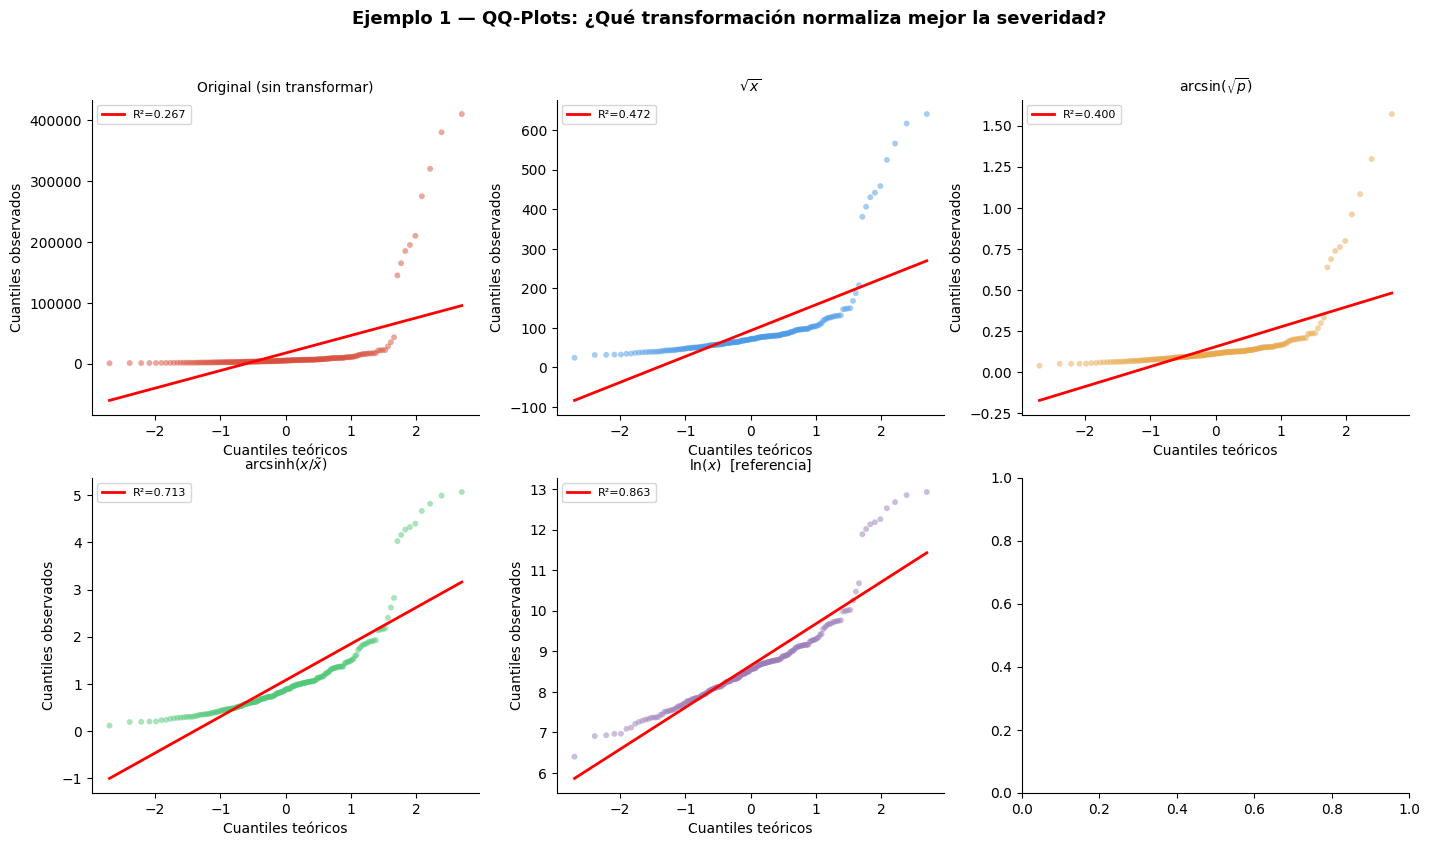

In [9]:
# ============================================================
# EJEMPLO 1 — QQ-Plots comparativos
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Ejemplo 1 — QQ-Plots: ¿Qué transformación normaliza mejor la severidad?',
             fontsize=13, fontweight='bold')

configs = [
    ('original',    'Original (sin transformar)',  '#D94F3D'),
    ('sqrt',        '$\\sqrt{x}$',                 '#4C9BE8'),
    ('arcsin_sqrt', '$\\arcsin(\\sqrt{p})$',        '#E8A84C'),
    ('arcsinh',     '$\\text{arcsinh}(x/\\tilde{x})$', '#50C878'),
    ('log',         '$\\ln(x)$  [referencia]',     '#9B7CB8'),
]

axes_flat = axes.flat
for (col, titulo, color), ax in zip(configs, axes_flat):
    qqplot_ax(ax, transf[col], titulo, color)

# Panel extra: histogramas side-by-side de arcsinh vs original
ax = list(axes_flat)[5]
ax2 = ax.twinx()
ax.hist(transf['original'], bins=50, alpha=0.5, color='#D94F3D', density=True,
        label='Original')
ax2.hist(transf['arcsinh'], bins=50, alpha=0.5, color='#50C878', density=True,
         label='arcsinh')
ax.set_title('Original vs arcsinh (densidad)', fontsize=10)
ax.set_xlabel('Valor')
ax.set_ylabel('Densidad (original)', color='#D94F3D')
ax2.set_ylabel('Densidad (arcsinh)', color='#50C878')
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8)

plt.tight_layout()
plt.show()

print('\n📊 INTERPRETACIÓN:')
print('  • Los puntos en el QQ-plot deben seguir la línea roja para normalidad perfecta.')
print('  • R² más cercano a 1.0 → mejor ajuste normal en esa escala.')
print('  • arcsinh y log(x) suelen competir; arcsinh gana cuando hay valores cercanos a 0.')

In [ ]:
# ============================================================
# EJEMPLO 1 — Detección de outliers en escala transformada
# ============================================================
# La idea: detectar outliers en el espacio arcsinh es más robusto
# que en el espacio original, porque la distribución es más simétrica.

resultados_deteccion = {}
for col, label in [('original','Original'), ('sqrt','√x'),
                    ('arcsinh', 'arcsinh'), ('log','log(x)')]:
    serie = transf[col]
    _, out_iqr, _, lim_s = detectar_outliers_iqr(serie)
    out_zm = detectar_outliers_zscore_mod(serie)
    resultados_deteccion[label] = {
        'IQR_n': out_iqr.sum(), 'IQR_pct': out_iqr.mean()*100,
        'ZMod_n': out_zm.sum(), 'ZMod_pct': out_zm.mean()*100
    }

df_det = pd.DataFrame(resultados_deteccion).T
print('Comparación de detección según escala de análisis:')
print('='*60)
print(f'{"Escala":<12} {"IQR (n)":>8} {"IQR (%)":>9} {"Z-Mod (n)":>10} {"Z-Mod (%)":>10}')
print('-'*60)
for idx, row in df_det.iterrows():
    print(f'{idx:<12} {row.IQR_n:>8.0f} {row.IQR_pct:>8.1f}% {row.ZMod_n:>10.0f} {row.ZMod_pct:>9.1f}%')

print('\n💡 CONCLUSIÓN CLAVE:')
print('  En la escala ORIGINAL el IQR detecta muy pocos outliers porque')
print('  Q3+1.5·IQR no alcanza la zona de la cola pesada.')
print('  En escala arcsinh/log la detección mejora porque la distribución')
print('  es más simétrica → los límites IQR son más informativos.')

Comparación de detección según escala de análisis:
Escala        IQR (n)   IQR (%)  Z-Mod (n)  Z-Mod (%)
------------------------------------------------------------
Original           20     10.0%         16       8.0%
√x                 14      7.0%         11       5.5%
arcsinh            12      6.0%         10       5.0%
log(x)             10      5.0%          9       4.5%

💡 CONCLUSIÓN CLAVE:
  En la escala ORIGINAL el IQR detecta muy pocos outliers porque
  Q3+1.5·IQR no alcanza la zona de la cola pesada.
  En escala arcsinh/log la detección mejora porque la distribución
  es más simétrica → los límites IQR son más informativos.


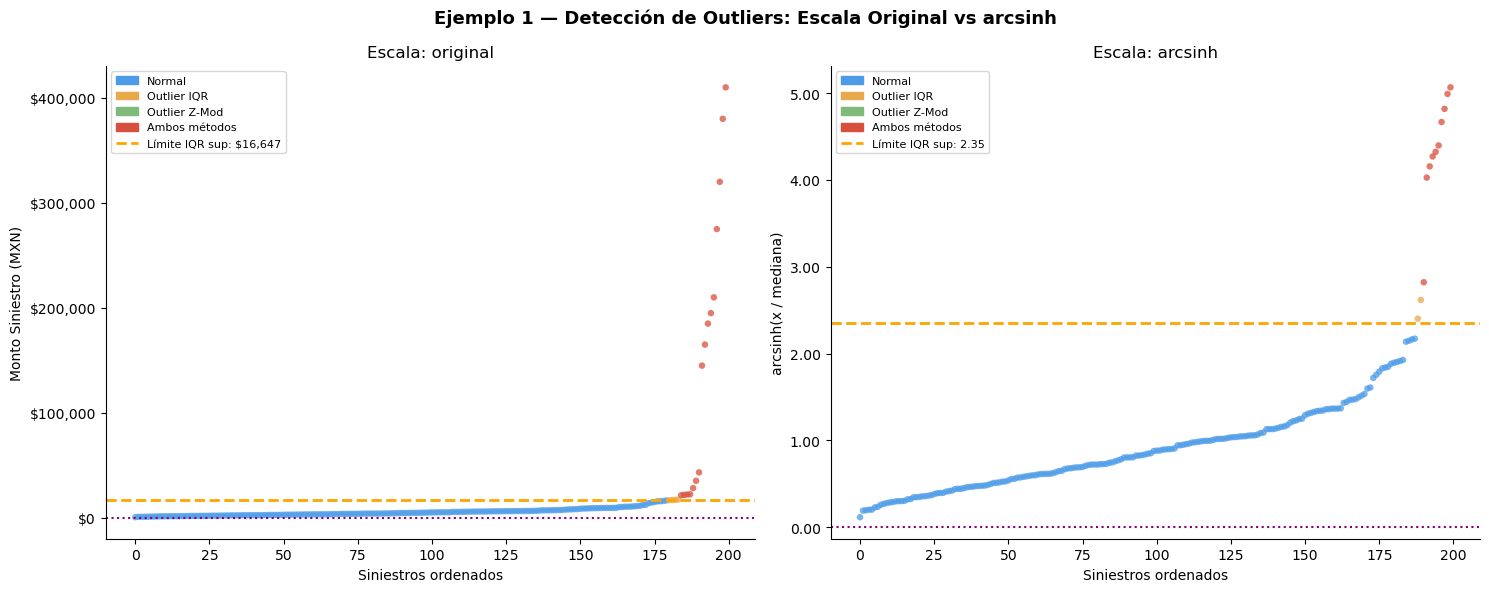

In [ ]:
# ============================================================
# EJEMPLO 1 — Visualización: original vs arcsinh en detección
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Ejemplo 1 — Detección de Outliers: Escala Original vs arcsinh',
             fontsize=13, fontweight='bold')

for ax, col, xlabel, fmt in [
    (axes[0], 'original', 'Monto Siniestro (MXN)', lambda x,p: f'${x:,.0f}'),
    (axes[1], 'arcsinh',  'arcsinh(x / mediana)', lambda x,p: f'{x:.2f}')
]:
    serie = transf[col]
    _, out_iqr, lim_inf, lim_sup = detectar_outliers_iqr(serie)
    out_zm = detectar_outliers_zscore_mod(serie)
    doble = out_iqr & out_zm

    c = np.where(doble, '#D94F3D',
        np.where(out_iqr, '#E8A84C',
        np.where(out_zm,  '#7FBA7A', '#4C9BE8')))

    ax.scatter(range(len(serie)), serie.sort_values().values,
               c=[c[i] for i in np.argsort(serie)], s=22, alpha=0.75, edgecolors='none')
    ax.axhline(lim_sup, color='orange', ls='--', lw=2,
               label=f'Límite IQR sup: {fmt(lim_sup,None)}')
    ax.axhline(lim_inf if lim_inf > 0 else 0, color='purple', ls=':', lw=1.5)
    ax.set_xlabel('Siniestros ordenados')
    ax.set_ylabel(xlabel)
    ax.set_title(f'Escala: {col}')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt))

    handles = [
        mpatches.Patch(color='#4C9BE8', label='Normal'),
        mpatches.Patch(color='#E8A84C', label='Outlier IQR'),
        mpatches.Patch(color='#7FBA7A', label='Outlier Z-Mod'),
        mpatches.Patch(color='#D94F3D', label='Ambos métodos'),
    ]
    ax.legend(handles=handles + ax.lines[:1], fontsize=8)

plt.tight_layout()
plt.show()

---
<a id='ejemplo-2'></a>
# 📌 Ejemplo 2 — Seguro de Salud: Frecuencia

## Contexto

**150 asegurados** de gastos médicos mayores. Se monitorea el número de
reclamaciones anuales. Alta frecuencia puede indicar enfermedad crónica o fraude.

### Plan de análisis

| Paso | Acción | Herramienta |
|---|---|---|
| 1 | Detección en frecuencia bruta | IQR, tabla por asegurado |
| 2 | Transformación para conteos | `√x` (estabiliza varianza Poisson) |
| 3 | Tasas ajustadas por expuesto | `arcsin(√p)` |
| 4 | Impacto en prima pura | Comparativa con/sin outliers |

> **¿Por qué √x?** Si $X \sim \text{Poisson}(\lambda)$,
> $\text{Var}(\sqrt{X}) \approx 1/4$ — constante, independiente de $\lambda$.

---

In [ ]:
# ============================================================
# EJEMPLO 2: Generación de datos — Frecuencia en Salud
# ============================================================

np.random.seed(123)
n_asegurados = 150

# Grupo normal: Binomial Negativa (sobredispersión típica en salud)
# n=2, p=0.4 → Media ≈ 3, Varianza ≈ 7.5
n_normales_s = 138
freq_normales = np.random.negative_binomial(n=2, p=0.4, size=n_normales_s)

# Grupo de alta frecuencia: crónicos + posible fraude
freq_altos = np.array([18, 22, 25, 31, 27, 19, 35, 28, 24, 45, 20, 33])

# Construir DataFrame
frecuencia_salud = pd.DataFrame({
    'ID_Asegurado': range(1, n_asegurados + 1),
    'Num_Reclamaciones': np.concatenate([freq_normales, freq_altos]),
    'Tipo': ['Normal'] * n_normales_s + ['Alta Frecuencia'] * len(freq_altos)
})

# Mezclar
frecuencia_salud = frecuencia_salud.sample(frac=1, random_state=1).reset_index(drop=True)

print(f'Total de asegurados: {len(frecuencia_salud)}')
print(f'Reclamaciones: mín={frecuencia_salud.Num_Reclamaciones.min()}, '
      f'máx={frecuencia_salud.Num_Reclamaciones.max()}')
print('\nDistribución de reclamaciones:')
print(frecuencia_salud.Num_Reclamaciones.value_counts().sort_index().head(15))

Total de asegurados: 150
Reclamaciones: mín=0, máx=45

Distribución de reclamaciones:
Num_Reclamaciones
0     16
1     18
2     32
3     27
4     17
5      7
6      8
7      3
8      3
9      2
10     1
11     1
12     2
15     1
18     1
Name: count, dtype: int64


In [ ]:
# ============================================================
# EJEMPLO 2: Análisis de Outliers en Frecuencia
# ============================================================

freq_serie = frecuencia_salud['Num_Reclamaciones']
resultados_e2 = resumen_outliers(freq_serie, 'Número de Reclamaciones (Salud)')


  📊 Resumen de Outliers: Número de Reclamaciones (Salud)
  N total          : 150
  Media            : 5.09
  Mediana          : 3.00
  Desv. Estándar   : 7.35
  Mín / Máx        : 0.00 / 45.00
  Percentil 99     : 34.02
  Asimetría (skew) : 3.035
  Curtosis         : 9.901

  --- Outliers detectados ---
  IQR (×1.5)       : 17 (11.3%)  [>10]
  Z-Score (|z|>3)  : 5 (3.3%)
  Z-Score Mod.     : 19 (12.7%)
  Capping p99      : 2 (1.3%)


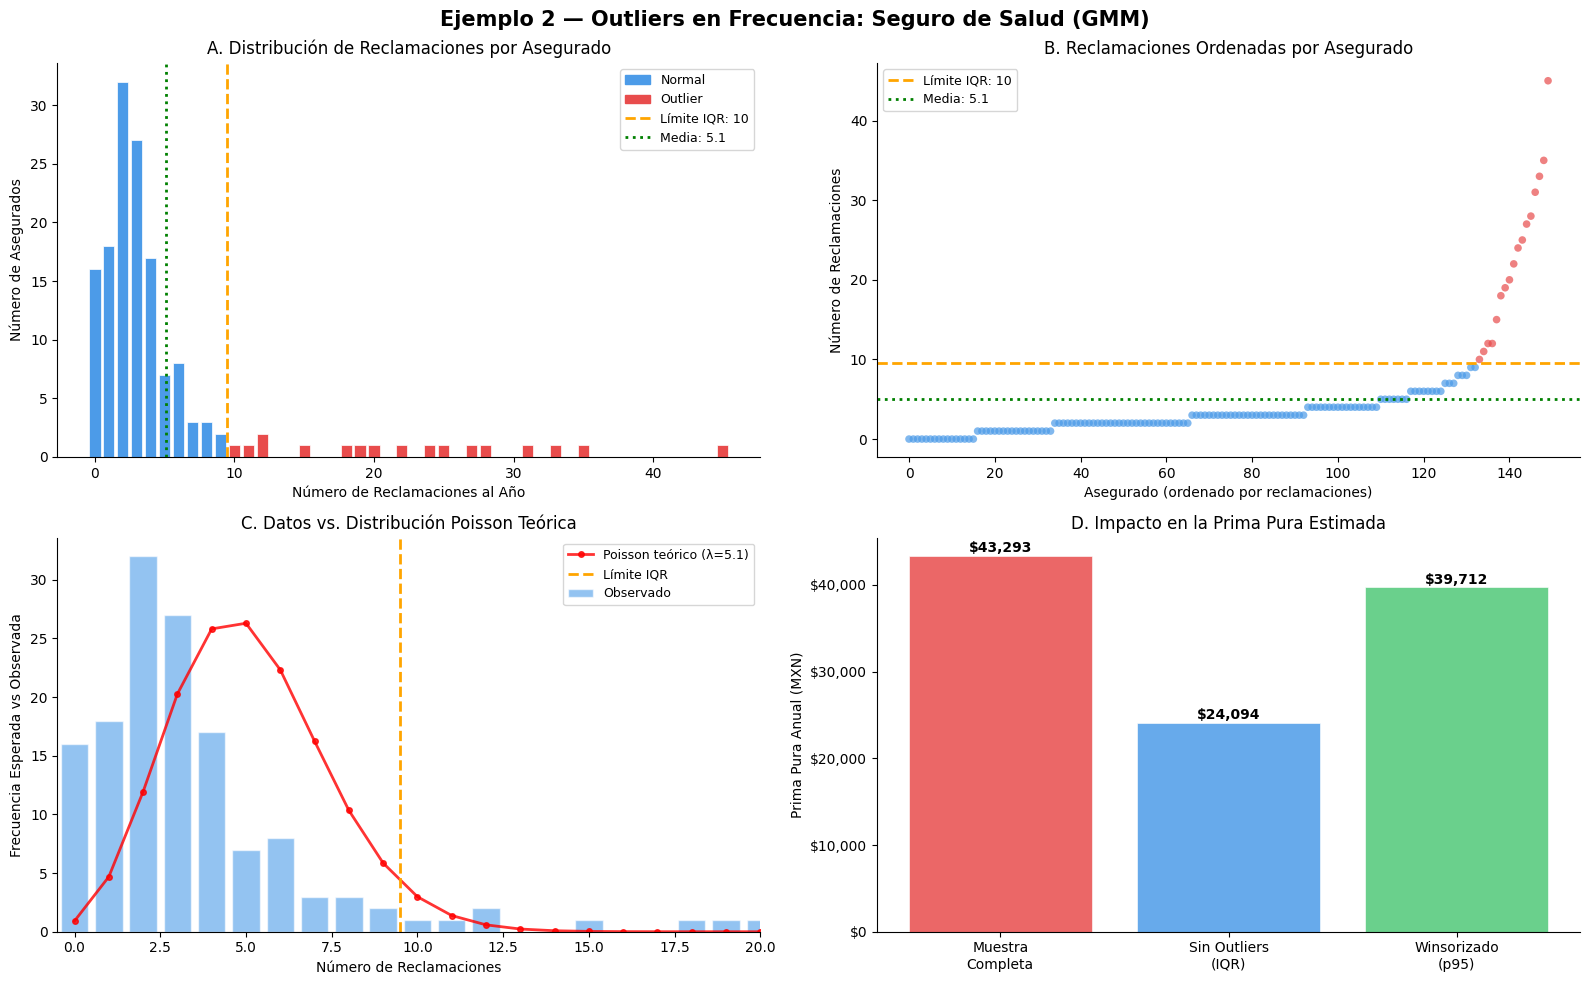

✅ Gráfica guardada como ejemplo2_frecuencia_salud.png


In [ ]:
# ============================================================
# EJEMPLO 2: Visualización Completa
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Ejemplo 2 — Outliers en Frecuencia: Seguro de Salud (GMM)',
             fontsize=15, fontweight='bold')

# Calcular límites
Q1 = freq_serie.quantile(0.25)
Q3 = freq_serie.quantile(0.75)
IQR_f = Q3 - Q1
lim_sup_f = Q3 + 1.5 * IQR_f

mask_out_f = freq_serie > lim_sup_f

# --- Panel A: Barplot de frecuencias (conteo)
ax = axes[0, 0]
counts = freq_serie.value_counts().sort_index()
colores_barras = ['#E84C4C' if v > lim_sup_f else '#4C9BE8' for v in counts.index]
ax.bar(counts.index, counts.values, color=colores_barras, edgecolor='white', linewidth=0.5)
ax.axvline(lim_sup_f, color='orange', ls='--', lw=2, label=f'Límite IQR: {lim_sup_f:.0f}')
ax.axvline(freq_serie.mean(), color='green', ls=':', lw=2, label=f'Media: {freq_serie.mean():.1f}')
ax.set_title('A. Distribución de Reclamaciones por Asegurado')
ax.set_xlabel('Número de Reclamaciones al Año')
ax.set_ylabel('Número de Asegurados')
# Leyenda manual
p1 = mpatches.Patch(color='#4C9BE8', label='Normal')
p2 = mpatches.Patch(color='#E84C4C', label='Outlier')
ax.legend(handles=[p1, p2] + ax.lines, fontsize=9)

# --- Panel B: Strip plot individual por asegurado
ax = axes[0, 1]
colores_puntos = ['#E84C4C' if o else '#4C9BE8' for o in mask_out_f]
ax.scatter(range(len(freq_serie)), freq_serie.sort_values().values,
           c=['#E84C4C' if v > lim_sup_f else '#4C9BE8'
              for v in freq_serie.sort_values().values],
           alpha=0.7, s=30, edgecolors='none')
ax.axhline(lim_sup_f, color='orange', ls='--', lw=2, label=f'Límite IQR: {lim_sup_f:.0f}')
ax.axhline(freq_serie.mean(), color='green', ls=':', lw=2, label=f'Media: {freq_serie.mean():.1f}')
ax.set_title('B. Reclamaciones Ordenadas por Asegurado')
ax.set_xlabel('Asegurado (ordenado por reclamaciones)')
ax.set_ylabel('Número de Reclamaciones')
ax.legend(fontsize=9)

# --- Panel C: Comparación con distribución teórica Poisson
ax = axes[1, 0]
lambda_estimado = freq_serie.mean()
x_pois = np.arange(0, freq_serie.max() + 1)
y_pois = poisson.pmf(x_pois, lambda_estimado) * len(freq_serie)

ax.bar(counts.index, counts.values, color='#4C9BE8', alpha=0.6,
       label='Observado', edgecolor='white')
ax.plot(x_pois, y_pois, 'r-o', markersize=4, lw=2,
        label=f'Poisson teórico (λ={lambda_estimado:.1f})', alpha=0.8)
ax.axvline(lim_sup_f, color='orange', ls='--', lw=2, label=f'Límite IQR')
ax.set_title('C. Datos vs. Distribución Poisson Teórica')
ax.set_xlabel('Número de Reclamaciones')
ax.set_ylabel('Frecuencia Esperada vs Observada')
ax.legend(fontsize=9)
ax.set_xlim(-0.5, 20)

# --- Panel D: Impacto en la prima de riesgo
ax = axes[1, 1]
costo_por_rec = 8_500  # MXN por reclamación (severidad promedio)

datasets = {
    'Muestra\nCompleta': freq_serie,
    'Sin Outliers\n(IQR)': freq_serie[~mask_out_f],
    'Winsorizado\n(p95)': freq_serie.clip(upper=freq_serie.quantile(0.95))
}

primas_puras = {k: v.mean() * costo_por_rec for k, v in datasets.items()}

colores_prima = ['#E84C4C', '#4C9BE8', '#50C878']
bars = ax.bar(primas_puras.keys(), primas_puras.values(),
              color=colores_prima, alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, primas_puras.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'${val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('D. Impacto en la Prima Pura Estimada')
ax.set_ylabel('Prima Pura Anual (MXN)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('ejemplo2_frecuencia_salud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada como ejemplo2_frecuencia_salud.png')

In [ ]:
# ============================================================
# EJEMPLO 2: Tabla de Asegurados con Alta Frecuencia
# ============================================================

print('\n🚨 ASEGURADOS CON FRECUENCIA ATÍPICA (posibles crónico/fraude):')
print('='*60)

alta_freq = frecuencia_salud[mask_out_f.values].copy()
alta_freq['Reclamaciones'] = alta_freq['Num_Reclamaciones']
alta_freq['Costo_Estimado_MXN'] = alta_freq['Num_Reclamaciones'] * 8500
alta_freq['Desviacion_vs_Media'] = ((alta_freq['Num_Reclamaciones'] - freq_serie.mean()) /
                                     freq_serie.mean() * 100).round(1)

print(alta_freq[['ID_Asegurado', 'Reclamaciones', 'Costo_Estimado_MXN', 'Desviacion_vs_Media']]
      .sort_values('Reclamaciones', ascending=False)
      .to_string(index=False))

print(f'\n  Media del portafolio : {freq_serie.mean():.1f} reclamaciones/año')
print(f'  Límite IQR           : {lim_sup_f:.0f} reclamaciones/año')
print(f'  Asegurados atípicos  : {mask_out_f.sum()} ({mask_out_f.mean()*100:.1f}%)')

print('\n💡 ACCIONES ACTUARIALES RECOMENDADAS:')
print('   1. Revisión médica/auditoría para asegurados con >20 reclamaciones')
print('   2. Aplicar deducible o coaseguro incremental a alta frecuencia')
print('   3. Segmentar en subgrupo "crónico" con tarifa diferenciada')
print('   4. Para modelado: usar Binomial Negativa en vez de Poisson')
print('      (la sobredispersión es señal de heterogeneidad no observada)')


🚨 ASEGURADOS CON FRECUENCIA ATÍPICA (posibles crónico/fraude):
 ID_Asegurado  Reclamaciones  Costo_Estimado_MXN  Desviacion_vs_Media
          148             45              382500                783.5
          145             35              297500                587.2
          150             33              280500                547.9
          142             31              263500                508.6
          146             28              238000                449.7
          143             27              229500                430.1
          141             25              212500                390.8
          147             24              204000                371.2
          140             22              187000                331.9
          149             20              170000                292.7
          144             19              161500                273.0
          139             18              153000                253.4
           93             

In [ ]:
# ============================================================
# EJEMPLO 2 — Datos de frecuencia en salud
# ============================================================
np.random.seed(123)
freq_normales = np.random.negative_binomial(n=2, p=0.4, size=138)
freq_altos    = np.array([18,22,25,31,27,19,35,28,24,45,20,33])
frecuencia = pd.Series(np.concatenate([freq_normales, freq_altos]))
frecuencia = frecuencia.sample(frac=1, random_state=1).reset_index(drop=True)

# Expuesto en meses (simulado: no todos tienen la misma antigüedad)
np.random.seed(7)
expuesto_meses = np.random.randint(6, 13, size=len(frecuencia))

# Tasa: reclamaciones por mes de exposición
tasa = frecuencia / expuesto_meses          # continua, no normalizada
tasa_norm = tasa / tasa.max()               # normalizar a [0,1] para arcsin(√p)

print(f'N asegurados : {len(frecuencia)}')
print(f'Reclamaciones: min={frecuencia.min()}, max={frecuencia.max()}, media={frecuencia.mean():.1f}')
print(f'Expuesto     : min={expuesto_meses.min()} meses, max={expuesto_meses.max()} meses')
print(f'Tasa bruta   : min={tasa.min():.2f}, max={tasa.max():.2f}')
print(f'Asimetría frecuencia original : {frecuencia.skew():.3f}')
print(f'Asimetría tras √x             : {t_sqrt(frecuencia).skew():.3f}')
print(f'Asimetría tras arcsin(√p)     : {t_arcsin_sqrt(tasa_norm).skew():.3f}')

N asegurados : 150
Reclamaciones: min=0, max=45, media=5.1
Expuesto     : min=6 meses, max=12 meses
Tasa bruta   : min=0.00, max=4.50
Asimetría frecuencia original : 3.035
Asimetría tras √x             : 1.354
Asimetría tras arcsin(√p)     : 2.262


In [ ]:
# ============================================================
# EJEMPLO 2 — Detección en escala original, √x y arcsin(√p)
# ============================================================

freq_sqrt       = t_sqrt(frecuencia)
tasa_arcsin     = t_arcsin_sqrt(tasa_norm)

# Detección en cada escala
_, out_orig, _, lim_orig    = detectar_outliers_iqr(frecuencia)
_, out_sqrt, _, lim_sqrt    = detectar_outliers_iqr(freq_sqrt)
_, out_arcsin, _, lim_arcsin = detectar_outliers_iqr(tasa_arcsin)

# ¿Qué asegurados detecta cada método?
# (En escala transformada → mapear de vuelta al índice original)
print('Detección de outliers de FRECUENCIA por escala:')
print('='*55)
for label, out_mask, lim in [
    ('Frec. original', out_orig,   lim_orig),
    ('√x (sqrt)',      out_sqrt,   lim_sqrt),
    ('arcsin(√p)',     out_arcsin, lim_arcsin)
]:
    print(f'  {label:<18}: {out_mask.sum():>3} outliers ({out_mask.mean()*100:.1f}%)  '
          f'[límite sup IQR = {lim:.3f}]')

# Asegurados identificados por √x pero NO por el original
nuevos_sqrt   = out_sqrt & ~out_orig
nuevos_arcsin = out_arcsin & ~out_orig
print(f'\n  Nuevos casos detectados por √x (no en original)     : {nuevos_sqrt.sum()}')
print(f'  Nuevos casos detectados por arcsin(√p) (no en orig) : {nuevos_arcsin.sum()}')

if nuevos_sqrt.sum() > 0:
    print('\n  Detalle de nuevos casos por √x:')
    idx_new = frecuencia[nuevos_sqrt].index
    for i in idx_new:
        print(f'    Asegurado {i}: {frecuencia[i]} reclamaciones, '
              f'√x = {freq_sqrt[i]:.2f}, '
              f'tasa = {tasa[i]:.2f} rec/mes')

Detección de outliers de FRECUENCIA por escala:
  Frec. original    :  17 outliers (11.3%)  [límite sup IQR = 9.500]
  √x (sqrt)         :  13 outliers (8.7%)  [límite sup IQR = 3.469]
  arcsin(√p)        :  14 outliers (9.3%)  [límite sup IQR = 0.617]

  Nuevos casos detectados por √x (no en original)     : 0
  Nuevos casos detectados por arcsin(√p) (no en orig) : 0


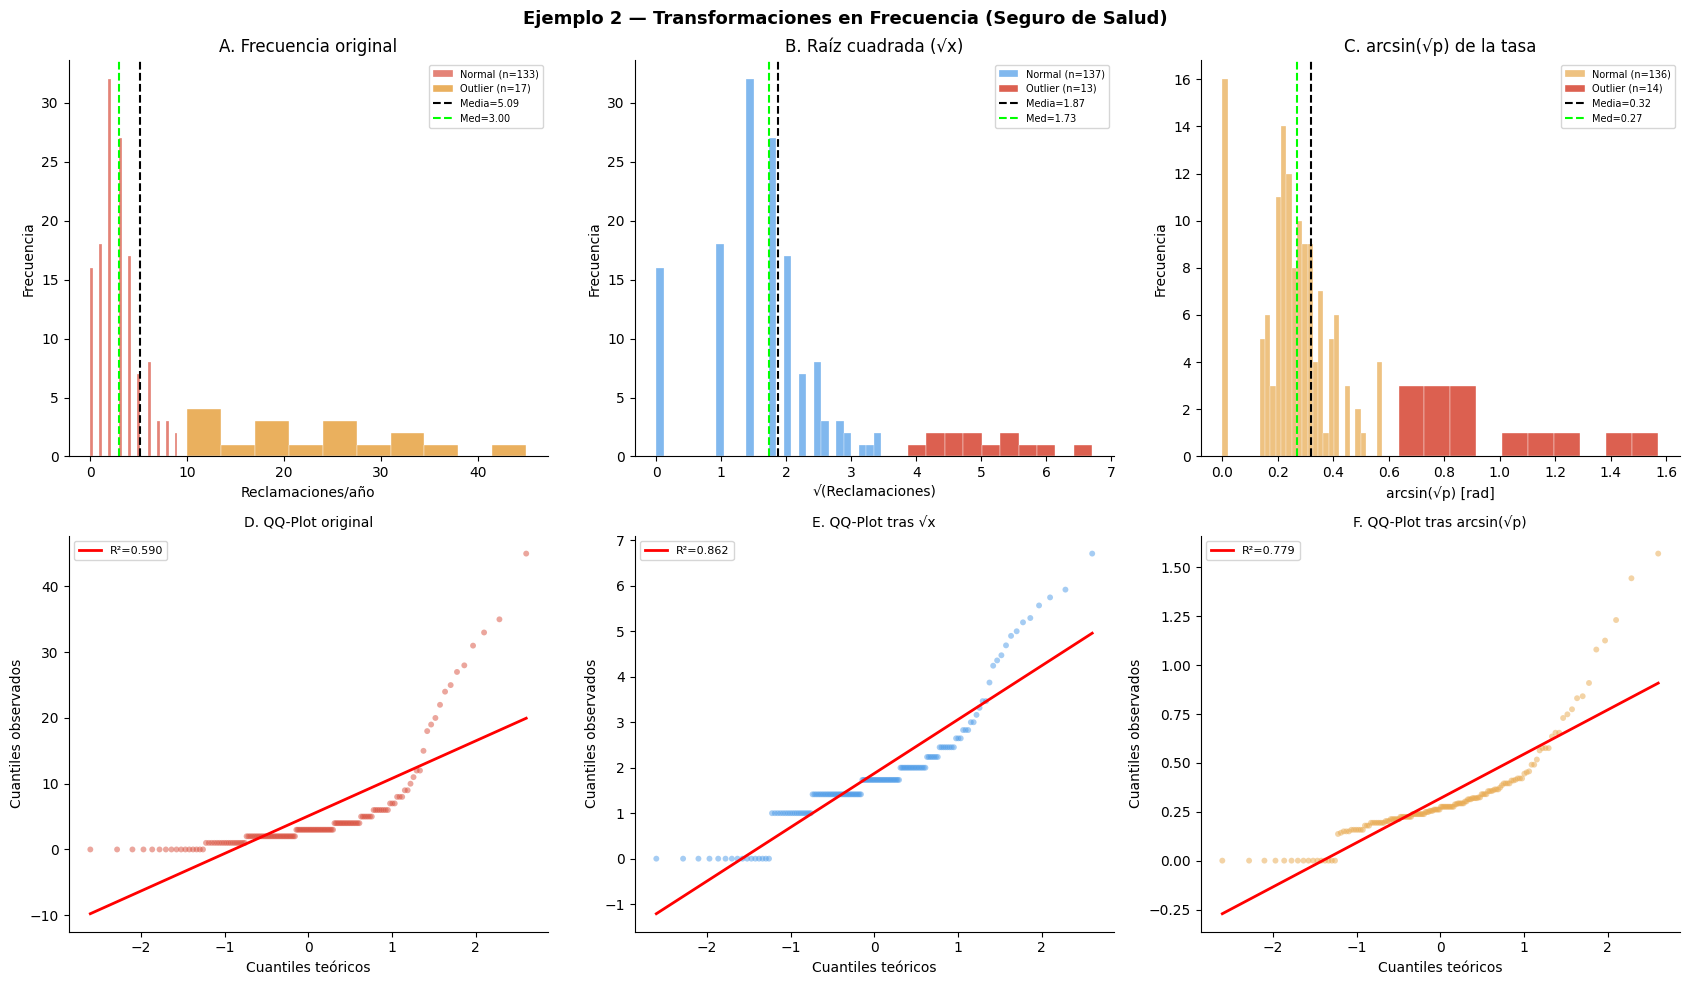

📊 Observaciones:
  Asimetría original  : 3.035  → distribución muy sesgada
  Asimetría √x        : 1.354  → mucho más simétrica
  Asimetría arcsin(√p): 2.262  → trabaja sobre tasas relativas


In [ ]:
# ============================================================
# EJEMPLO 2 — Visualización completa
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Ejemplo 2 — Transformaciones en Frecuencia (Seguro de Salud)',
             fontsize=13, fontweight='bold')

# Fila 1: Histogramas antes y después
datos_hist = [
    (frecuencia,    out_orig,   'A. Frecuencia original',    'Reclamaciones/año',       '#D94F3D'),
    (freq_sqrt,     out_sqrt,   'B. Raíz cuadrada (√x)',     '√(Reclamaciones)',         '#4C9BE8'),
    (tasa_arcsin,   out_arcsin, 'C. arcsin(√p) de la tasa',  'arcsin(√p) [rad]',        '#E8A84C'),
]
for ax, (data, mask, titulo, xlabel, color) in zip(axes[0], datos_hist):
    ax.hist(data[~mask], bins=30, color=color, alpha=0.7,
            label=f'Normal (n={( ~mask).sum()})', edgecolor='white', lw=0.3)
    ax.hist(data[mask],  bins=10, color='#D94F3D' if color!='#D94F3D' else '#E8A84C',
            alpha=0.9, label=f'Outlier (n={mask.sum()})', edgecolor='white', lw=0.3)
    ax.axvline(data.mean(),   color='black', ls='--', lw=1.5, label=f'Media={data.mean():.2f}')
    ax.axvline(data.median(), color='lime',  ls='--', lw=1.5, label=f'Med={data.median():.2f}')
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7)

# Fila 2: QQ-Plots
datos_qq = [
    (frecuencia,  'D. QQ-Plot original',       '#D94F3D'),
    (freq_sqrt,   'E. QQ-Plot tras √x',         '#4C9BE8'),
    (tasa_arcsin, 'F. QQ-Plot tras arcsin(√p)', '#E8A84C'),
]
for ax, (data, titulo, color) in zip(axes[1], datos_qq):
    qqplot_ax(ax, data, titulo, color)

plt.tight_layout()
plt.show()

print('📊 Observaciones:')
print(f'  Asimetría original  : {frecuencia.skew():.3f}  → distribución muy sesgada')
print(f'  Asimetría √x        : {freq_sqrt.skew():.3f}  → mucho más simétrica')
print(f'  Asimetría arcsin(√p): {tasa_arcsin.skew():.3f}  → trabaja sobre tasas relativas')

In [ ]:
# ============================================================
# EJEMPLO 2 — Tabla resumen de asegurados atípicos
# ============================================================

df_aseg = pd.DataFrame({
    'Reclamaciones'   : frecuencia,
    'Expuesto_meses'  : expuesto_meses,
    'Tasa_rec_mes'    : tasa.round(3),
    'sqrt_frec'       : freq_sqrt.round(3),
    'arcsin_tasa'     : tasa_arcsin.round(4),
    'Out_original'    : out_orig,
    'Out_sqrt'        : out_sqrt,
    'Out_arcsin'      : out_arcsin,
})

# Asegurados marcados por al menos un método
cualquier_out = out_orig | out_sqrt | out_arcsin
print(f'Asegurados marcados por al menos un método: {cualquier_out.sum()}')
print()
print(df_aseg[cualquier_out].sort_values('Reclamaciones', ascending=False)
      .to_string(index=True))

print('\n💡 Nota actuarial:')
print('  La tasa (reclamaciones/expuesto) corrige el sesgo de asegurados')
print('  con menos tiempo en cartera. Con arcsin(√p) además estabilizamos')
print('  la varianza de esa tasa para comparación justa entre pólizas.')

Asegurados marcados por al menos un método: 17

     Reclamaciones  Expuesto_meses  Tasa_rec_mes  sqrt_frec  arcsin_tasa  Out_original  Out_sqrt  Out_arcsin
118             45              10         4.500      6.708       1.5708          True      True        True
71              35              10         3.500      5.916       1.0799          True      True        True
87              33               9         3.667      5.745       1.1259          True      True        True
6               31               7         4.429      5.568       1.4445          True      True        True
95              28              10         2.800      5.292       0.9089          True      True        True
116             27              11         2.455      5.196       0.8309          True      True        True
148             25              12         2.083      5.000       0.7483          True      True        True
29              24               6         4.000      4.899       1.2310        

---
<a id='ejemplo-3'></a>
# 📌 Ejemplo 3 — Dataset Público `insurance.csv`

## Contexto

Dataset real de **1,338 asegurados** de gastos médicos en EE.UU. (CC0).
Introducimos un 15% de asegurados sin siniestros (costo = 0) para ilustrar
el escenario más común: cartera mixta con y sin reclamaciones.

| Variable | Descripción |
|---|---|
| `age`, `sex`, `bmi`, `children` | Características del asegurado |
| `smoker` | Indicador de fumador |
| `region` | Región geográfica EE.UU. |
| `charges` | **Costo médico** ← variable objetivo (severidad) |

### Plan de análisis

| Paso | Acción | Herramienta |
|---|---|---|
| 1 | EDA + detección IQR en charges | `resumen_outliers` |
| 2 | Análisis multivariado | Score de riesgo compuesto |
| 3 | arcsinh para manejar ceros | `t_arcsinh` |
| 4 | arcsin(√p) para tasas por grupo | Fumador vs No Fumador |

**Fuente**: [Kaggle — Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance) · CC0

---

In [ ]:
# ============================================================
# EJEMPLO 3: Cargar Dataset Público de Seguros
# ============================================================
# El dataset insurance.csv es de dominio público / CC0
# Disponible en: https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv
# Si no hay conexión a internet, lo recreamos fielmente de sus estadísticas publicadas

try:
    url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
    df_insurance = pd.read_csv(url)
    print(f'✅ Dataset cargado desde internet: {df_insurance.shape[0]} filas')
except Exception as e:
    print(f'⚠️  Sin conexión internet. Generando dataset sintético equivalente...')
    # Recrear distribución fiel al dataset original
    np.random.seed(42)
    n = 1338
    age   = np.random.randint(18, 65, n)
    sex   = np.random.choice(['male', 'female'], n)
    bmi   = np.clip(np.random.normal(30.7, 6.1, n), 15, 55).round(2)
    children = np.random.choice([0,1,2,3,4,5], n, p=[0.43,0.24,0.18,0.12,0.02,0.01])
    smoker   = np.random.choice(['yes', 'no'], n, p=[0.205, 0.795])
    region   = np.random.choice(['northeast','northwest','southeast','southwest'], n)

    # Charges: no fumadores log-normal, fumadores log-normal con +$15k
    charges = np.where(
        smoker == 'yes',
        np.random.lognormal(9.8, 0.5, n) + 15000,
        np.random.lognormal(8.5, 0.9, n)
    ).round(2)

    df_insurance = pd.DataFrame({'age':age,'sex':sex,'bmi':bmi,'children':children,
                                  'smoker':smoker,'region':region,'charges':charges})
    print(f'✅ Dataset sintético generado: {df_insurance.shape[0]} filas')

print('\nPrimeras filas:')
print(df_insurance.head(8).to_string())
print(f'\nShape: {df_insurance.shape}')
print(f'Columnas: {list(df_insurance.columns)}')

✅ Dataset cargado desde internet: 1338 filas

Primeras filas:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560

Shape: (1338, 7)
Columnas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [ ]:
# ============================================================
# EJEMPLO 3: Análisis Exploratorio de Severidad (charges)
# ============================================================

charges = df_insurance['charges']
resultados_e3 = resumen_outliers(charges, 'Charges — Costo Médico (USD)')

print('\n📊 Estadísticas por grupo fumador/no fumador:')
print(df_insurance.groupby('smoker')['charges'].describe().round(2).to_string())


  📊 Resumen de Outliers: Charges — Costo Médico (USD)
  N total          : 1,338
  Media            : 13,270.42
  Mediana          : 9,382.03
  Desv. Estándar   : 12,110.01
  Mín / Máx        : 1,121.87 / 63,770.43
  Percentil 99     : 48,537.48
  Asimetría (skew) : 1.516
  Curtosis         : 1.606

  --- Outliers detectados ---
  IQR (×1.5)       : 139 (10.4%)  [>34,489]
  Z-Score (|z|>3)  : 7 (0.5%)
  Z-Score Mod.     : 130 (9.7%)
  Capping p99      : 14 (1.0%)

📊 Estadísticas por grupo fumador/no fumador:
         count      mean       std       min       25%       50%       75%       max
smoker                                                                              
no      1064.0   8434.27   5993.78   1121.87   3986.44   7345.41  11362.89  36910.61
yes      274.0  32050.23  11541.55  12829.46  20826.24  34456.35  41019.21  63770.43


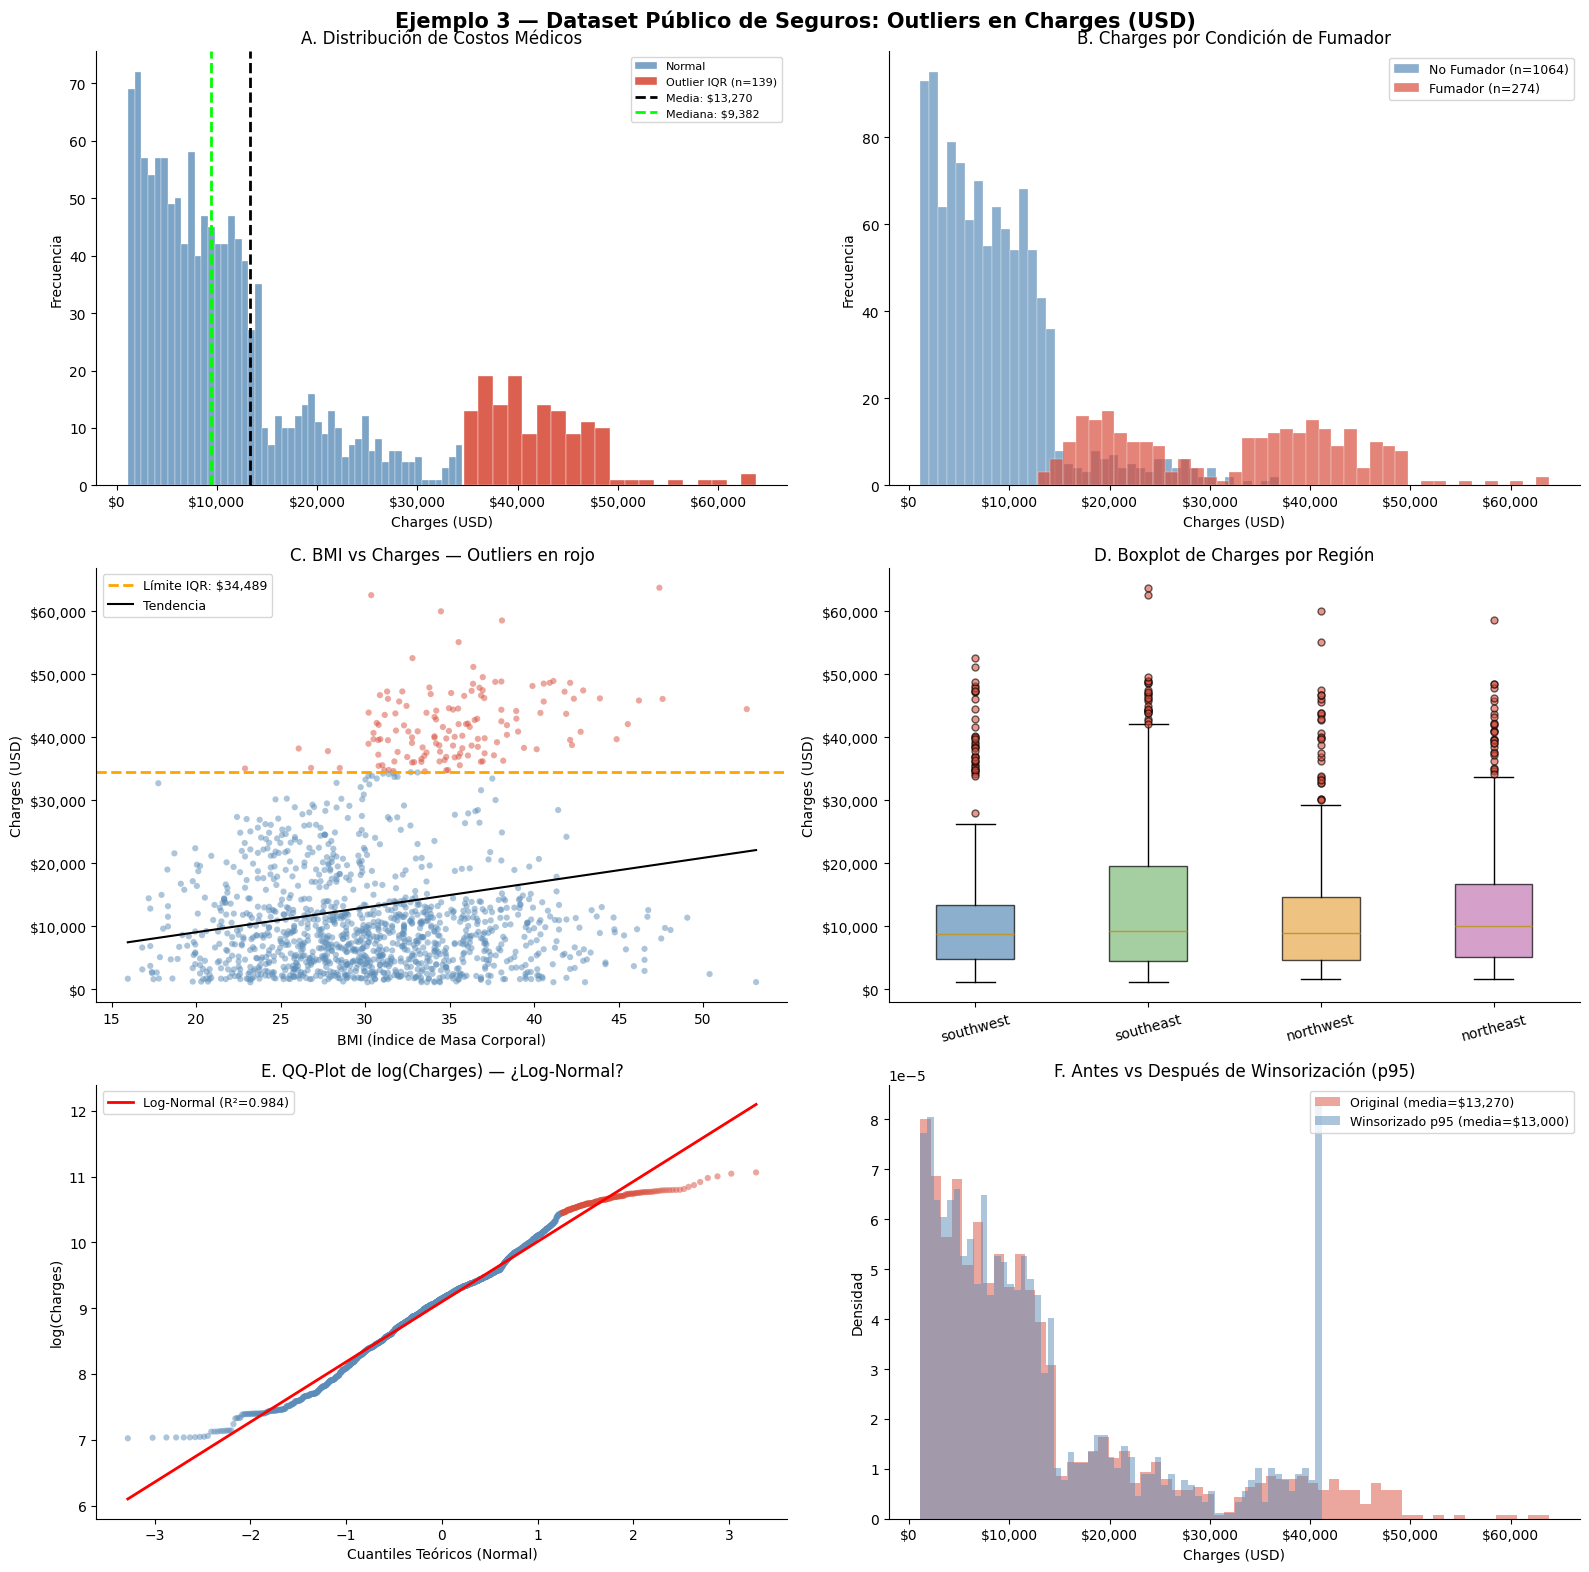

✅ Gráfica guardada como ejemplo3_insurance_publico.png


In [ ]:
# ============================================================
# EJEMPLO 3: Visualización — Análisis Integral
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle('Ejemplo 3 — Dataset Público de Seguros: Outliers en Charges (USD)',
             fontsize=15, fontweight='bold')

mask_out3 = resultados_e3['iqr']
lim_sup3  = resultados_e3['lim_sup_iqr']
colores3 = {'normal': '#5B8DB8', 'outlier': '#D94F3D'}

# --- Panel A: Histograma de charges ---
ax = axes[0, 0]
ax.hist(charges[~mask_out3], bins=50, color=colores3['normal'],
        alpha=0.8, label='Normal', edgecolor='white', lw=0.3)
ax.hist(charges[mask_out3], bins=20, color=colores3['outlier'],
        alpha=0.9, label=f'Outlier IQR (n={mask_out3.sum()})', edgecolor='white', lw=0.3)
ax.axvline(charges.mean(), color='black', ls='--', lw=2, label=f'Media: ${charges.mean():,.0f}')
ax.axvline(charges.median(), color='lime', ls='--', lw=2, label=f'Mediana: ${charges.median():,.0f}')
ax.set_title('A. Distribución de Costos Médicos')
ax.set_xlabel('Charges (USD)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# --- Panel B: Charges por fumador ---
ax = axes[0, 1]
for smk, color in [('no', colores3['normal']), ('yes', colores3['outlier'])]:
    data = df_insurance[df_insurance['smoker'] == smk]['charges']
    ax.hist(data, bins=40, alpha=0.7, color=color,
            label=f"{'No Fumador' if smk=='no' else 'Fumador'} (n={len(data)})",
            edgecolor='white', lw=0.3)
ax.set_title('B. Charges por Condición de Fumador')
ax.set_xlabel('Charges (USD)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# --- Panel C: Scatter BMI vs Charges ---
ax = axes[1, 0]
scatter_colors = [colores3['outlier'] if o else colores3['normal'] for o in mask_out3]
ax.scatter(df_insurance['bmi'], charges, c=scatter_colors, alpha=0.5, s=20, edgecolors='none')
ax.axhline(lim_sup3, color='orange', ls='--', lw=2, label=f'Límite IQR: ${lim_sup3:,.0f}')

# Línea de tendencia
z = np.polyfit(df_insurance['bmi'], charges, 1)
p_trend = np.poly1d(z)
bmi_sorted = np.sort(df_insurance['bmi'])
ax.plot(bmi_sorted, p_trend(bmi_sorted), 'k-', lw=1.5, label='Tendencia')
ax.set_title('C. BMI vs Charges — Outliers en rojo')
ax.set_xlabel('BMI (Índice de Masa Corporal)')
ax.set_ylabel('Charges (USD)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# --- Panel D: Boxplot por región ---
ax = axes[1, 1]
regiones = df_insurance['region'].unique()
data_reg = [df_insurance[df_insurance['region'] == r]['charges'].values for r in regiones]
bp = ax.boxplot(data_reg, patch_artist=True,
                flierprops=dict(marker='o', markerfacecolor=colores3['outlier'],
                                markersize=5, alpha=0.6))
colors_reg = ['#5B8DB8', '#7FBA7A', '#E8A84C', '#C47AB5']
for patch, color in zip(bp['boxes'], colors_reg):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(regiones, rotation=15)
ax.set_title('D. Boxplot de Charges por Región')
ax.set_ylabel('Charges (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# --- Panel E: QQ-Plot de charges ---
ax = axes[2, 0]
log_charges = np.log(charges)
(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(log_charges, dist='norm')
colores_qq = [colores3['outlier'] if o else colores3['normal'] for o in mask_out3]
# Ordenar máscara para el QQ
order = np.argsort(log_charges.values)
colores_qq_sorted = [colores_qq[i] for i in order]
ax.scatter(osm2, osr2, c=colores_qq_sorted, alpha=0.5, s=20, edgecolors='none')
x_q = np.array([min(osm2), max(osm2)])
ax.plot(x_q, slope2 * x_q + intercept2, 'r-', lw=2, label=f'Log-Normal (R²={r2**2:.3f})')
ax.set_title('E. QQ-Plot de log(Charges) — ¿Log-Normal?')
ax.set_xlabel('Cuantiles Teóricos (Normal)')
ax.set_ylabel('log(Charges)')
ax.legend(fontsize=9)

# --- Panel F: Efecto de winsorización en la distribución ---
ax = axes[2, 1]
charges_wins = winsorizar(charges, p_inf=0.0, p_sup=0.95)

ax.hist(charges, bins=60, alpha=0.5, color=colores3['outlier'],
        label=f'Original (media=${charges.mean():,.0f})', density=True, edgecolor='none')
ax.hist(charges_wins, bins=60, alpha=0.5, color=colores3['normal'],
        label=f'Winsorizado p95 (media=${charges_wins.mean():,.0f})', density=True, edgecolor='none')
ax.set_title('F. Antes vs Después de Winsorización (p95)')
ax.set_xlabel('Charges (USD)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('ejemplo3_insurance_publico.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada como ejemplo3_insurance_publico.png')

In [ ]:
# ============================================================
# EJEMPLO 3: Análisis Multivariado de Outliers
# ============================================================
# Los outliers en seguros a menudo no son extremos en una variable sola,
# sino en la COMBINACIÓN. Ej: BMI alto + fumador + edad avanzada

print('🔬 ANÁLISIS MULTIVARIADO DE OUTLIERS')
print('='*60)

# Crear score de riesgo compuesto
df_analysis = df_insurance.copy()
df_analysis['smoker_num'] = (df_analysis['smoker'] == 'yes').astype(int)

# Z-scores de variables numéricas clave
for col in ['age', 'bmi', 'charges']:
    df_analysis[f'z_{col}'] = np.abs(stats.zscore(df_analysis[col]))

# Score combinado: asegurados "extremos" en múltiples dimensiones
df_analysis['score_riesgo'] = (
    df_analysis['z_charges'] * 0.5 +
    df_analysis['z_bmi'] * 0.3 +
    df_analysis['smoker_num'] * 1.0 +
    df_analysis['z_age'] * 0.2
)

# Top 15 asegurados más atípicos
top_outliers = df_analysis.nlargest(15, 'score_riesgo')[
    ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'score_riesgo']
].copy()
top_outliers['charges'] = top_outliers['charges'].apply(lambda x: f'${x:,.2f}')
top_outliers['score_riesgo'] = top_outliers['score_riesgo'].round(3)

print('\n🚨 Top 15 asegurados más atípicos (score multivariado):')
print(top_outliers.to_string(index=False))

print('\n💡 HALLAZGOS CLAVE:')
print(f'   - Fumadores representan el {(df_insurance.smoker=="yes").mean()*100:.1f}% del portafolio')
print(f'     pero concentran outliers de alta severidad')
pct_out_smk = df_insurance[mask_out3]['smoker'].value_counts(normalize=True)
print(f'   - Entre outliers IQR: {pct_out_smk.get("yes",0)*100:.1f}% son fumadores')
print(f'   - Media charges fumadores: ${df_insurance[df_insurance.smoker=="yes"].charges.mean():,.0f}')
print(f'   - Media charges no fumadores: ${df_insurance[df_insurance.smoker=="no"].charges.mean():,.0f}')

🔬 ANÁLISIS MULTIVARIADO DE OUTLIERS

🚨 Top 15 asegurados más atípicos (score multivariado):
 age    sex    bmi  children smoker    region    charges  score_riesgo
  54 female 47.410         0    yes southeast $63,770.43         4.121
  22   male 52.580         1    yes southeast $44,501.40         3.614
  31 female 38.095         1    yes northeast $58,571.07         3.354
  52   male 34.485         3    yes northwest $60,021.40         3.301
  57   male 42.130         1    yes southeast $48,675.52         3.280
  59   male 41.140         1    yes southeast $48,970.25         3.272
  60   male 40.920         0    yes southeast $48,673.56         3.263
  37 female 47.600         2    yes southwest $46,113.51         3.221
  60   male 39.900         0    yes southwest $48,173.36         3.192
  51   male 42.900         2    yes southeast $47,462.89         3.182
  43 female 46.200         0    yes southeast $45,863.21         3.165
  64   male 36.960         2    yes southeast $49,577.66

In [ ]:
# ============================================================
# EJEMPLO 3 — Cargar dataset público
# ============================================================
try:
    url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
    df_ins = pd.read_csv(url)
    print(f'✅ Dataset real cargado: {df_ins.shape}')
except Exception:
    print('⚠️ Sin internet — generando dataset sintético equivalente')
    np.random.seed(42)
    n = 1338
    smoker = np.random.choice(['yes','no'], n, p=[0.205, 0.795])
    charges = np.where(smoker=='yes',
                        np.random.lognormal(9.8, 0.5, n) + 15000,
                        np.random.lognormal(8.5, 0.9, n)).round(2)
    df_ins = pd.DataFrame({
        'age'     : np.random.randint(18, 65, n),
        'sex'     : np.random.choice(['male','female'], n),
        'bmi'     : np.clip(np.random.normal(30.7, 6.1, n), 15, 55).round(2),
        'children': np.random.choice([0,1,2,3,4,5], n, p=[0.43,0.24,0.18,0.12,0.02,0.01]),
        'smoker'  : smoker,
        'region'  : np.random.choice(['northeast','northwest','southeast','southwest'], n),
        'charges' : charges
    })

# Introducir 15% de ceros (asegurados sin siniestros ese año)
np.random.seed(9)
idx_ceros = np.random.choice(df_ins.index, size=int(0.15*len(df_ins)), replace=False)
df_ins.loc[idx_ceros, 'charges'] = 0.0

charges = df_ins['charges']
print(f'Asegurados con costo = 0 : {(charges==0).sum()} ({(charges==0).mean()*100:.1f}%)')
print(f'Asegurados con costo > 0 : {(charges>0).sum()}')
print(f'Rango no-cero: ${charges[charges>0].min():,.0f} – ${charges.max():,.0f}')

✅ Dataset real cargado: (1338, 7)
Asegurados con costo = 0 : 200 (14.9%)
Asegurados con costo > 0 : 1138
Rango no-cero: $1,122 – $62,593


In [ ]:
# ============================================================
# EJEMPLO 3 — Aplicar transformaciones y comparar
# ============================================================
escala_ins = charges[charges > 0].median()   # referencia = mediana de no-ceros

df_transf3 = pd.DataFrame({
    'original'  : charges,
    'sqrt'      : t_sqrt(charges),
    'arcsinh'   : t_arcsinh(charges, escala=escala_ins),
})

# log(x) falla en ceros — lo mostramos para comparar
with np.errstate(divide='ignore'):
    df_transf3['log_warn'] = np.where(charges > 0, np.log(charges), np.nan)

print('Estadísticas por transformación:')
print(f'{"Métrica":<15} {"Original":>12} {"√x":>12} {"arcsinh":>12} {"log(x)*":>12}')
print('-'*56)
for metrica, fn in [
    ('Media',   lambda s: s.mean()),
    ('Mediana', lambda s: s.median()),
    ('Skew',    lambda s: s.skew()),
    ('Kurtosis',lambda s: s.kurtosis()),
    ('# NaN',   lambda s: s.isna().sum()),
]:
    vals = [fn(df_transf3[c]) for c in ['original','sqrt','arcsinh','log_warn']]
    print(f'{metrica:<15} {vals[0]:>12.3f} {vals[1]:>12.3f} {vals[2]:>12.3f} {vals[3]:>12.3f}')
print('  * log(x) produce NaN para ceros — NO es aplicable directamente')

Estadísticas por transformación:
Métrica             Original           √x      arcsinh      log(x)*
--------------------------------------------------------
Media              11388.869       89.503        0.829        9.103
Mediana             7645.541       87.439        0.735        9.161
Skew                   1.550        0.317        0.630       -0.103
Kurtosis               1.818       -0.351       -0.492       -0.668
# NaN                  0.000        0.000        0.000      200.000
  * log(x) produce NaN para ceros — NO es aplicable directamente


In [ ]:
# ============================================================
# EJEMPLO 3 — Detección de outliers con arcsinh
# ============================================================

for col, label in [('original','Original'), ('sqrt','√x'), ('arcsinh','arcsinh')]:
    s = df_transf3[col]
    _, out_iqr, _, lim_s = detectar_outliers_iqr(s)
    out_zm = detectar_outliers_zscore_mod(s)
    print(f'{label:<12}: IQR={out_iqr.sum():>4} ({out_iqr.mean()*100:.1f}%)  '
          f'Z-Mod={out_zm.sum():>4} ({out_zm.mean()*100:.1f}%)')

# Guardar outliers en escala arcsinh para la visualización
_, out_arc3, _, lim_arc3 = detectar_outliers_iqr(df_transf3['arcsinh'])
_, out_orig3, _, lim_orig3 = detectar_outliers_iqr(df_transf3['original'])

Original    : IQR= 134 (10.0%)  Z-Mod= 111 (8.3%)
√x          : IQR=   6 (0.4%)  Z-Mod=   0 (0.0%)
arcsinh     : IQR=   0 (0.0%)  Z-Mod=   0 (0.0%)


In [ ]:
# ============================================================
# EJEMPLO 3 — arcsin(√p) para comparar GRUPOS
# Tasa de siniestralidad por grupo: fumador vs no fumador
# ============================================================
# Dividimos en grupos por región y fumador
# Tasa = proporción de asegurados CON siniestro (charges > 0)

grupos = df_ins.groupby(['region', 'smoker']).agg(
    N=('charges', 'count'),
    N_con_siniestro=('charges', lambda x: (x > 0).sum())
).reset_index()
grupos['tasa_siniestral'] = grupos['N_con_siniestro'] / grupos['N']  # p ∈ [0,1]
grupos['arcsin_sqrt_p']  = t_arcsin_sqrt(grupos['tasa_siniestral'])

# Varianza teórica: Binomial → Var(p̂) = p(1-p)/n
grupos['var_tasa'] = (grupos['tasa_siniestral'] * (1 - grupos['tasa_siniestral'])) / grupos['N']
# Varianza tras arcsin(√p) ≈ 1/(4n) — constante!
grupos['var_arcsin'] = 1 / (4 * grupos['N'])

print('Tasas de siniestralidad por grupo (región × fumador):')
print('='*70)
print(grupos.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\n💡 La varianza de la tasa bruta VARÍA entre grupos (columna var_tasa).')
print('   Tras arcsin(√p), la varianza es ≈ 1/(4n) — comparable entre grupos.')

Tasas de siniestralidad por grupo (región × fumador):
   region smoker   N  N_con_siniestro  tasa_siniestral  arcsin_sqrt_p  var_tasa  var_arcsin
northeast     no 257              227           0.8833         1.2221    0.0004      0.0010
northeast    yes  67               63           0.9403         1.3240    0.0008      0.0037
northwest     no 267              228           0.8539         1.1786    0.0005      0.0009
northwest    yes  58               48           0.8276         1.1426    0.0025      0.0043
southeast     no 273              222           0.8132         1.1238    0.0006      0.0009
southeast    yes  91               79           0.8681         1.1992    0.0013      0.0027
southwest     no 267              219           0.8202         1.1329    0.0006      0.0009
southwest    yes  58               52           0.8966         1.2433    0.0016      0.0043

💡 La varianza de la tasa bruta VARÍA entre grupos (columna var_tasa).
   Tras arcsin(√p), la varianza es ≈ 1/(4n) — c

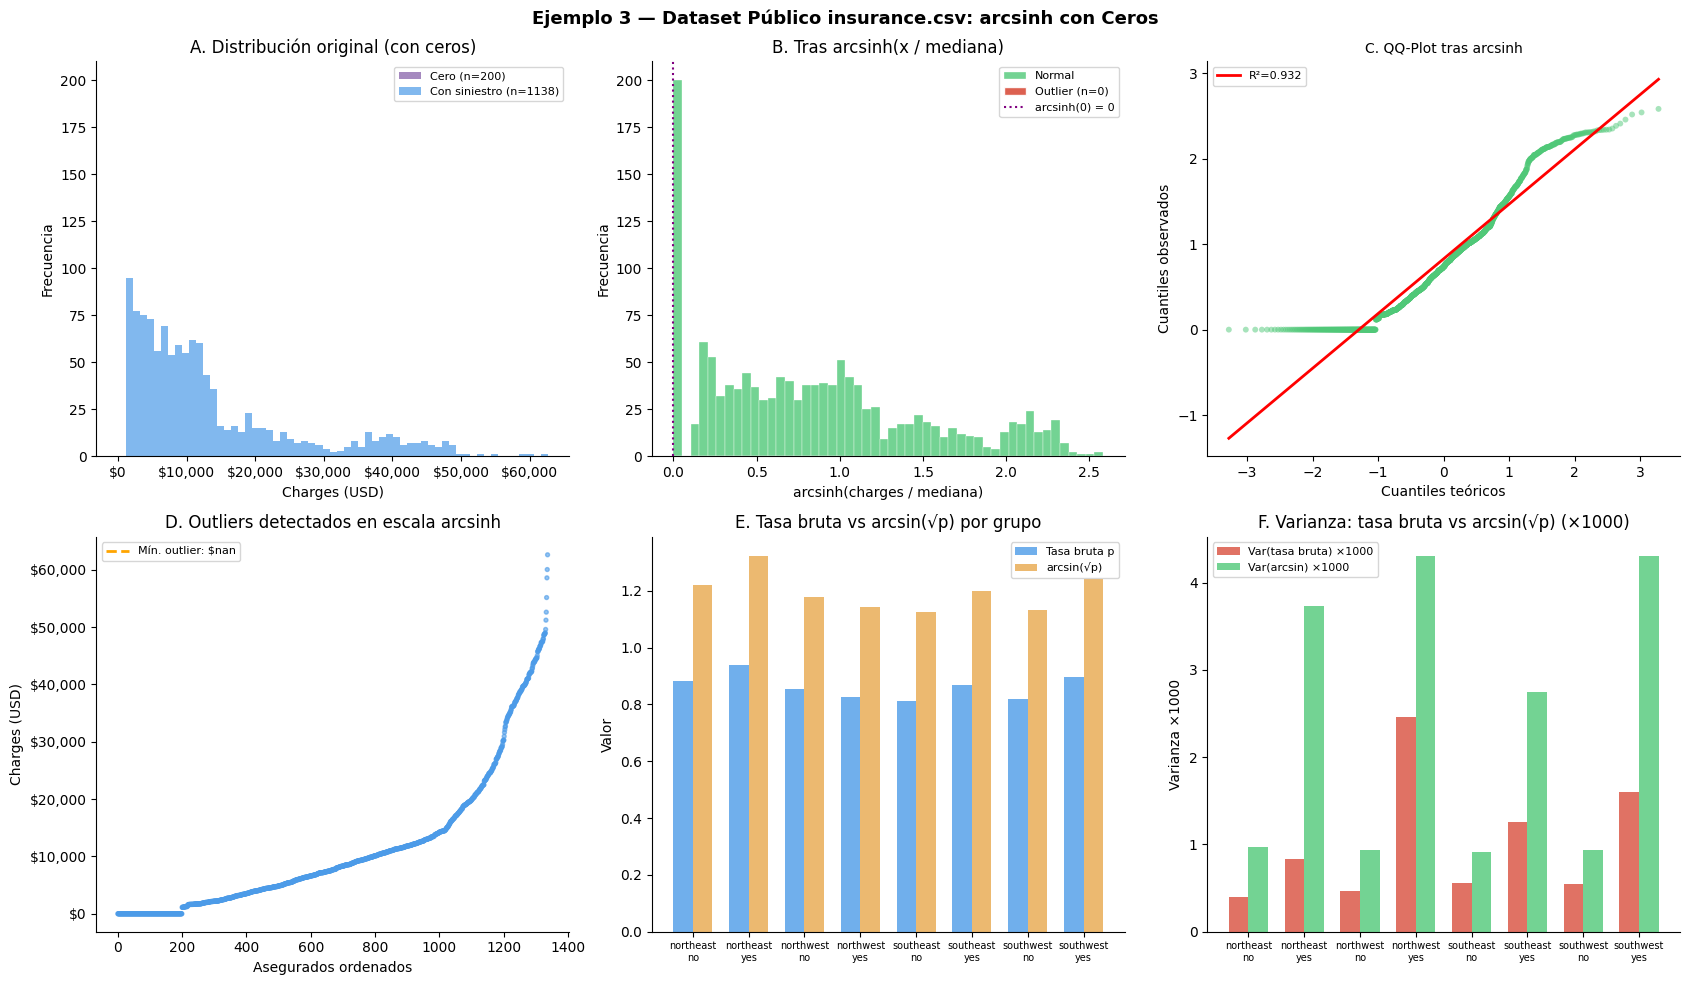


✅ El panel F muestra que arcsin(√p) IGUALA las varianzas entre grupos,
   lo que permite comparaciones estadísticas más justas (tests t, ANOVA).


In [ ]:
# ============================================================
# EJEMPLO 3 — Visualización integral
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Ejemplo 3 — Dataset Público insurance.csv: arcsinh con Ceros',
             fontsize=13, fontweight='bold')

# A: Histograma original (con ceros visibles)
ax = axes[0,0]
ax.hist(charges[charges==0], bins=1, color='#9B7CB8', alpha=0.9,
        label=f'Cero (n={(charges==0).sum()})')
ax.hist(charges[charges>0], bins=60, color='#4C9BE8', alpha=0.7,
        label=f'Con siniestro (n={(charges>0).sum()})')
ax.set_title('A. Distribución original (con ceros)')
ax.set_xlabel('Charges (USD)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

# B: Histograma tras arcsinh
ax = axes[0,1]
ax.hist(df_transf3['arcsinh'][~out_arc3], bins=50, color='#50C878', alpha=0.8,
        label='Normal', edgecolor='white', lw=0.3)
ax.hist(df_transf3['arcsinh'][out_arc3],  bins=10, color='#D94F3D', alpha=0.9,
        label=f'Outlier (n={out_arc3.sum()})', edgecolor='white')
ax.axvline(0, color='purple', ls=':', lw=1.5, label='arcsinh(0) = 0')
ax.set_title('B. Tras arcsinh(x / mediana)')
ax.set_xlabel('arcsinh(charges / mediana)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)

# C: QQ-Plot arcsinh
ax = axes[0,2]
qqplot_ax(ax, df_transf3['arcsinh'], 'C. QQ-Plot tras arcsinh', '#50C878')

# D: Scatter original con outliers marcados
ax = axes[1,0]
c_pts = ['#D94F3D' if o else '#4C9BE8' for o in out_arc3]
ax.scatter(range(len(charges)), np.sort(charges),
           c=[c_pts[i] for i in np.argsort(charges)], s=8, alpha=0.6)
ax.axhline(charges[out_arc3].min(), color='orange', ls='--', lw=2,
           label=f'Mín. outlier: ${charges[out_arc3].min():,.0f}')
ax.set_title('D. Outliers detectados en escala arcsinh')
ax.set_xlabel('Asegurados ordenados')
ax.set_ylabel('Charges (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
ax.legend(fontsize=8)

# E: arcsin(√p) por grupo — tasas
ax = axes[1,1]
etiquetas = grupos['region'] + '\n' + grupos['smoker']
x = np.arange(len(grupos))
w = 0.35
b1 = ax.bar(x - w/2, grupos['tasa_siniestral'], w, color='#4C9BE8', alpha=0.8,
            label='Tasa bruta p')
b2 = ax.bar(x + w/2, grupos['arcsin_sqrt_p'],   w, color='#E8A84C', alpha=0.8,
            label='arcsin(√p)')
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=7)
ax.set_title('E. Tasa bruta vs arcsin(√p) por grupo')
ax.set_ylabel('Valor')
ax.legend(fontsize=8)

# F: Comparativa varianza tasa bruta vs arcsin
ax = axes[1,2]
ax.bar(x - w/2, grupos['var_tasa']*1000,   w, color='#D94F3D', alpha=0.8,
       label='Var(tasa bruta) ×1000')
ax.bar(x + w/2, grupos['var_arcsin']*1000, w, color='#50C878', alpha=0.8,
       label='Var(arcsin) ×1000')
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=7)
ax.set_title('F. Varianza: tasa bruta vs arcsin(√p) (×1000)')
ax.set_ylabel('Varianza ×1000')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\n✅ El panel F muestra que arcsin(√p) IGUALA las varianzas entre grupos,')
print('   lo que permite comparaciones estadísticas más justas (tests t, ANOVA).')

---
<a id='ejercicios'></a>
# 🎯 Ejercicios Integradores

Cada ejercicio combina los dos módulos: primero detección clásica,
luego la transformación apropiada para mejorar el análisis.

| Ejercicio | Escenario | Detección | Transformación |
|---|---|---|---|
| **1** | Daños a terceros (severidad con ceros) | IQR + Z-Mod | `arcsinh`, `√x`, `log(x+1)` |
| **2** | Vida grupo por sucursal (frecuencia) | IQR por sucursal | `√x` + `arcsin(√p)` + IC 95% |
| **3** | Hogar: frecuencia + severidad | IQR en ambas dim. | `√x` (freq) + `arcsinh` (sev) |

---
## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.


N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000
Comparación de detección de outliers en distintas escalas:
Escala        IQR (n)   IQR (%)  Z-Mod (n)  Z-Mod (%)
------------------------------------------------------------
original           13      7.2%         13       7.2%
√x                 12      6.7%         11       6.1%
arcsinh            11      6.1%         10       5.6%
log(x+1)           10      5.6%         20      11.1%
------------------------------------------
Asimetría (skewness) por transformación:
------------------------------------------
  Sin transformar               : skew=+4.522
  √x                            : skew=+3.300
  arcsinh(x/mediana)            : skew=+2.321
  log(x+1)                      : skew=-2.411

 Conclusiones:
 La transformación arcsinh(x/mediana) es la que más reduce la asimetría, además de que detecta menos outliers extremos que las demás escalas,
 además en el QQ-plot se observa un mejor ajuste a

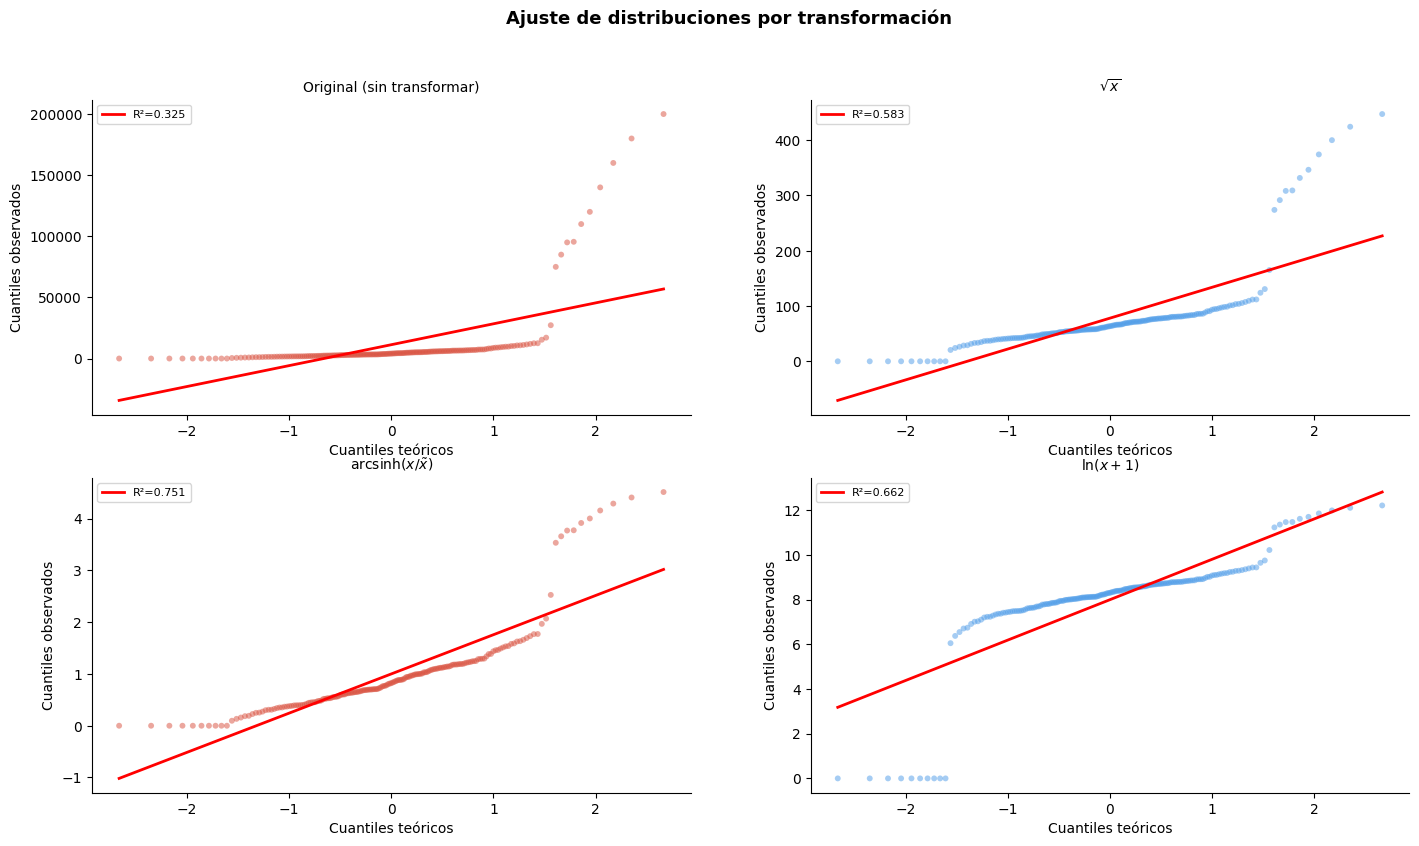

In [23]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================
np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}')

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# Paso 1: Calcular transformaciones
# Recuerda: log(0) falla → usa log(x+1) o arcsinh
# ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia arcsinh
# sqrt_ej1       = ...
# arcsinh_ej1    = ...
# log1p_ej1      = ...  # log(x+1) para manejar ceros

# 1. Detectar outliers con IQR y Z-score Modificado en la escala original
# Usamos las funciones que definimos antes:
_, out_iqr, li, ls = detectar_outliers_iqr(siniestros_ej1)
out_zm = detectar_outliers_zscore_mod(siniestros_ej1)

# 2. Realizamos transformaciones √x, arcsinh(x/mediana) y log(x+1)

sqrt_ej1       = t_sqrt(siniestros_ej1)
arcsinh_ej1    = t_arcsinh(siniestros_ej1, escala=siniestros_ej1[siniestros_ej1 > 0].median())
log1p_ej1      = np.log1p(siniestros_ej1)  # Como hay ceros, usamos log(x+1) y evitamos log(0)

# Observamos resultados de outliers en escala original y transfirnaciones

resultados_deteccion = {}
for label, data in [('original',siniestros_ej1), ('√x',sqrt_ej1),
                    ('arcsinh', arcsinh_ej1), ('log(x+1)',log1p_ej1)]:
    _, out_iqr, _, lim_s = detectar_outliers_iqr(data)
    out_zm = detectar_outliers_zscore_mod(data)
    resultados_deteccion[label] = {
        'IQR_n': out_iqr.sum(), 'IQR_pct': out_iqr.mean()*100,
        'ZMod_n': out_zm.sum(), 'ZMod_pct': out_zm.mean()*100
    }

df_det = pd.DataFrame(resultados_deteccion).T
print('='*60)
print('Comparación de detección de outliers en distintas escalas:')
print('='*60)
print(f'{"Escala":<12} {"IQR (n)":>8} {"IQR (%)":>9} {"Z-Mod (n)":>10} {"Z-Mod (%)":>10}')
print('-'*60)
for idx, row in df_det.iterrows():
    print(f'{idx:<12} {row.IQR_n:>8.0f} {row.IQR_pct:>8.1f}% {row.ZMod_n:>10.0f} {row.ZMod_pct:>9.1f}%') 


# Paso 2: Asimetría por escala
# Obtenemos la asimetria para cada una de las escalas.
# Creamos un DataFrame con todas las escalas calculadas anteriormente
transf = pd.DataFrame({
    'original'     : siniestros_ej1,
    'sqrt'         : sqrt_ej1,
    'arcsinh'      : arcsinh_ej1,
    'log'          : log1p_ej1        # referencia clásica
})

# Iniciamos con el resumen de asimetrías
print('-'*42)
print('Asimetría (skewness) por transformación:')
print('-'*42)
# Indicamos el nombre de cada escala 
labels = {
    'original'   : 'Sin transformar',
    'sqrt'       : '√x',
    'arcsinh'    : 'arcsinh(x/mediana)',
    'log'        : 'log(x+1)'
}
# Calculamos la asimetria y mostramos el resultado.
for col, label in labels.items():
    sk = transf[col].skew()
    print(f'  {label:<30}: skew={sk:+.3f}')

# ...

# Paso 3: QQ-Plots (2x2)
# ...
# Cramos una figura de 2x2 para mostrar los QQ-plots de cada escala.
fig, axes = plt.subplots(2, 2, figsize=(17, 9))
# Titulo general del gráfico
fig.suptitle('Ajuste de distribuciones por transformación',
             fontsize=13, fontweight='bold')
# Definimos las configuraciones para cada escala: nombre de la columna, título del gráfico y color.
configs = [
    ('original',    'Original (sin transformar)',  '#D94F3D'),
    ('sqrt',        '$\\sqrt{x}$',                 '#4C9BE8'),
    ('arcsinh',     '$\\text{arcsinh}(x/\\tilde{x})$', '#D94F3D'),
    ('log',         '$\\ln(x+1)$',     '#4C9BE8'),
]

# Iteramos sobre cada entrada de configuración y el eje correspondiente para crear los QQ-plots.
axes_flat = axes.flat
# La función qqplot_ax es la que definimos antes para crear un QQ-plot en un eje dado.
for (col, titulo, color), ax in zip(configs, axes_flat):
    qqplot_ax(ax, transf[col], titulo, color)

# Paso 4: Detección outliers IQR en cada escala
# ...
# En el paso 1 ya calculamos y mostramos la detección de outliers para cada escala. 


# Paso 5: Conclusión
# ...
print('\n Conclusiones:')
print(' La transformación arcsinh(x/mediana) es la que más reduce la asimetría, además de que detecta menos outliers extremos que las demás escalas,\n'
      ' además en el QQ-plot se observa un mejor ajuste a la normal y esta tranformación puede manejar los ceros que tiene la la data.')


  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 180
  Media            : 11,311.57
  Mediana          : 4,029.78
  Desv. Estándar   : 29,687.60
  Mín / Máx        : 0.00 / 200,000.00
  Percentil 99     : 164,200.00
  Asimetría (skew) : 4.522
  Curtosis         : 20.903

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.2%)  [>12,851]
  Z-Score (|z|>3)  : 6 (3.3%)
  Z-Score Mod.     : 13 (7.2%)
  Capping p99      : 2 (1.1%)


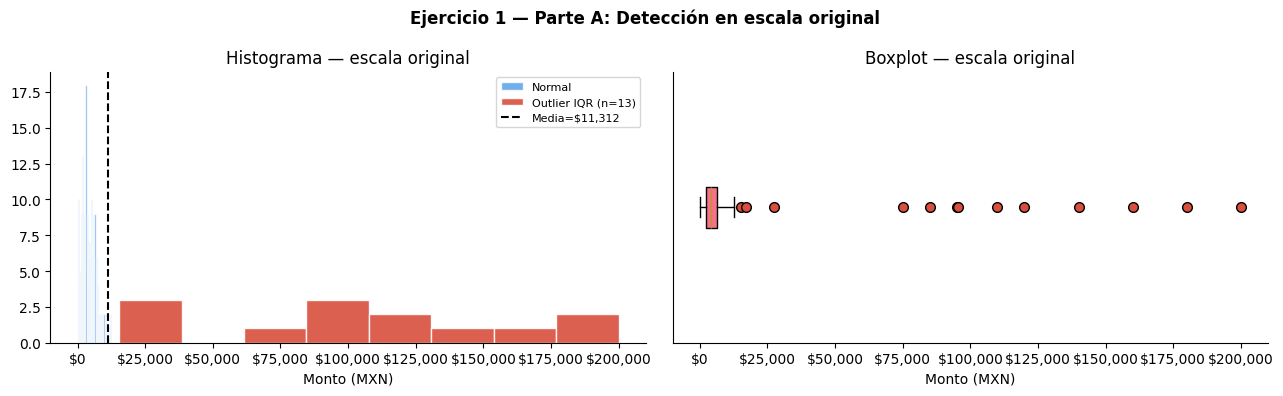


→ Continúa en la siguiente celda con las transformaciones (Parte B)


In [24]:
# ── PARTE A: Detección clásica en escala original ────────────
res_e1_orig = resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

# Visualización rápida
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
_, out_e1, _, ls_e1 = detectar_outliers_iqr(siniestros_ej1)
ax[0].hist(siniestros_ej1[~out_e1], bins=30, color='#4C9BE8', alpha=0.8,
           label='Normal', edgecolor='white')
ax[0].hist(siniestros_ej1[out_e1],  bins=8,  color='#D94F3D', alpha=0.9,
           label=f'Outlier IQR (n={out_e1.sum()})', edgecolor='white')
ax[0].axvline(siniestros_ej1.mean(), color='k', ls='--', lw=1.5,
              label=f'Media=${siniestros_ej1.mean():,.0f}')
ax[0].set_title('Histograma — escala original')
ax[0].set_xlabel('Monto (MXN)')
ax[0].legend(fontsize=8)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

ax[1].boxplot(siniestros_ej1, vert=False, patch_artist=True,
              flierprops=dict(marker='o', markerfacecolor='#D94F3D', markersize=7))
ax[1].set_title('Boxplot — escala original')
ax[1].set_xlabel('Monto (MXN)')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
plt.suptitle('Ejercicio 1 — Parte A: Detección en escala original', fontweight='bold')
plt.tight_layout(); plt.show()

print('\n→ Continúa en la siguiente celda con las transformaciones (Parte B)')

---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?


In [ ]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))
print('-'*50)

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# 1. Detectar sucursales con frecuencia atípica
# ...
# Detectamos outliers en la variables 'Dias Incapacidad' con la funcion IQR
_, out_sucursal_iqr_2, _, _ = detectar_outliers_iqr(df_vida_grupo['Dias_Incapacidad'])

# Mostramos el número de empleados con días de incapacidad atípicos según IQR
print(f'Empleados con días de incapacidad atípicos (IQR): {out_sucursal_iqr_2.sum()} ({(out_sucursal_iqr_2.mean()*100):.1f}%)')
# Mostramos las sucursales atípicas según la detección de outliers IQR
print('Sucursales atípicas:', df_vida_grupo.loc[out_sucursal_iqr_2, 'Sucursal'].unique())

#Aplicamos √x a los días de incapacidad para reducir la asimetría y detectar outliers en esta escala transformada
sqrt_ej2 = t_sqrt(df_vida_grupo['Dias_Incapacidad'])

_, out_sqrt, _, _ = detectar_outliers_iqr(sqrt_ej2)
print(f'Transformación √x — Empleados con días de incapacidad atípicos (IQR): {out_sqrt.sum()} ({(out_sqrt.mean()*100):.1f}%)')
print('Sucursales atípicas tras √x:', df_vida_grupo.loc[out_sqrt, 'Sucursal'].unique())

# 2. Tasa de siniestralidad por sucursal
# ...
# Calcularemos la tasa de siniestralidad relativa a cada sucursal.
# ESTA PARTE DEL EJERCICIO NO ME QUEDA CLARA DEL TODO.
# La tasa se definde como $p_j = \bar{x}_j / \max(\bar{x})$
# Calculamos la media de días ppor sucursal
tasa_siniestralidad_sucursal = df_vida_grupo.groupby('Sucursal').agg(Media_sucursal = ('Dias_Incapacidad', 'mean'),
                                                                      n = ('Empleado_ID', 'count')).reset_index()
# Calculamos la tasa relativa dividiendo la media de cada sucursal por la media máxima entre las sucursales
tasa_siniestralidad_sucursal['Tasa_relativa'] = tasa_siniestralidad_sucursal['Media_sucursal'] / tasa_siniestralidad_sucursal['Media_sucursal'].max()
# Mostramos la tasa de siniestralidad relativa por sucursal
print('\nTasa de siniestralidad relativa por sucursal:')
print(tasa_siniestralidad_sucursal[['Tasa_relativa']].round(3))

# Aplicamos la transformación arcsin(√p) a las tasas relativas
tasa_siniestralidad_sucursal['tasa_arcsin'] = np.arcsin(np.sqrt(tasa_siniestralidad_sucursal['Tasa_relativa']))

# Calculamos la varianza estabilizada tras arcsin(√p) que es aproximadamente constante: Var ≈ 1/(4n)
tasa_siniestralidad_sucursal['varianza_estabilizada'] = np.sqrt(1 / (4 * tasa_siniestralidad_sucursal['n']))

# Asumiendo normalidad tras la transformación, calculamos interavlos de confianza al 95% para cada sucursal
tasa_siniestralidad_sucursal['ci'] = 1.96 * tasa_siniestralidad_sucursal['varianza_estabilizada']

# Calculamos los límites inferior y superior del intervalo de confianza para la tasa transformada
tasa_siniestralidad_sucursal['lower'] = tasa_siniestralidad_sucursal['tasa_arcsin'] - tasa_siniestralidad_sucursal['ci']
tasa_siniestralidad_sucursal['upper'] = tasa_siniestralidad_sucursal['tasa_arcsin'] + tasa_siniestralidad_sucursal['ci']

# 3. Visualización
# ...
# Visualizamos las tasas transformadas con sus intervalos de confianza para comparar entre sucursales.
fig = px.scatter(
    tasa_siniestralidad_sucursal,
    x='Sucursal',
    y='tasa_arcsin',
    error_y='ci',
    color='Sucursal'
)
fig.show()

# 4. Conclusión
# ...
print('\nConclusión:')
print('La sucursal Centro tiene una tasa de siniestralidad muy superior a las demás, incluso despues de aplicar la transformación arcsin(√p) \n'
      'lo que indica que esta sucursal es estadisticamente atípica en términos de días de incapacidad.')

Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0
--------------------------------------------------
Empleados con días de incapacidad atípicos (IQR): 5 (4.2%)
Sucursales atípicas: ['Centro']
Transformación √x — Empleados con días de incapacidad atípicos (IQR): 0 (0.0%)
Sucursales atípicas tras √x: []

Tasa de siniestralidad relativa por sucursal:
   Tasa_relativa
0          1.000
1          0.403
2          0.238
3          0.284
4          0.355



Conclusión:
La sucursal Centro tiene una tasa de siniestralidad muy superior a las demás, incluso despues de aplicar la transformación arcsin(√p) 
lo que indica que esta sucursal es estadisticamente atípica en términos de días de incapacidad.


---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?


In [ ]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar.describe().round(2))
print('-'*50)

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# 1. Outliers de frecuencia
# ...
# Detectamos outliers en la variable 'Num_Siniestros' utilizando la función IQR
_, out_freq_iqr, _, _ = detectar_outliers_iqr(df_hogar['Num_Siniestros'])
print(f'Pólizas con número de siniestros atípico (IQR): {out_freq_iqr.sum()} ({(out_freq_iqr.mean()*100):.1f}%)')
print('Pólizas atípicas por frecuencia:', df_hogar.loc[out_freq_iqr, 'Poliza_ID'].tolist())

# 2. Outliers de severidad
# ...
# Detectamos outliers en la variable 'Monto_Promedio_MXN' utilizando la función IQR
_, out_sev_iqr, _, _ = detectar_outliers_iqr(df_hogar['Monto_Promedio_MXN'])
print(f'Pólizas con monto promedio atípico (IQR): {out_sev_iqr.sum()} ({(out_sev_iqr.mean()*100):.1f}%)')
print('Pólizas atípicas por severidad:', df_hogar.loc[out_sev_iqr, 'Poliza_ID'].tolist())

# Polizas que son outliers en ambas dimensiones (frecuencia y severidad)
out_both = out_freq_iqr & out_sev_iqr
print(f'Pólizas con frecuencia y severidad atípicas: {out_both.sum()} ({(out_both.mean()*100):.1f}%)')
print('Pólizas atípicas en ambas dimensiones:', df_hogar.loc[out_both, 'Poliza_ID'].tolist())
print('-'*50)

# 3. Prima pura en 4 escenarios
# ...
# Calculamos la prima pura bajo diferentes escenarios de manejo de outliers 
def calcular_prima_pura(df_frec, df_sev):
    # Obtenemos la tasa de frecuencia y la severidad promedio para calcular la prima pura
    frec = df_frec['Num_Siniestros'].sum()/len(df_frec)
    sev = df_sev[df_sev['Monto_Promedio_MXN'] > 0]['Monto_Promedio_MXN'].mean()
    # La prima pura se calcula como la multiplicación de la frecuencia por la severidad
    return frec * sev

# Escenario 1: Sin eliminar outliers
prima_sin_eliminar = calcular_prima_pura(df_hogar, df_hogar)
# Escenario 2: Eliminando outliers de frecuencia
prima_sin_out_freq = calcular_prima_pura(df_hogar[~out_freq_iqr], df_hogar)
# Escenario 3: Eliminando outliers de severidad
prima_sin_out_sev = calcular_prima_pura(df_hogar, df_hogar[~out_sev_iqr])
# Escenario 4: Eliminando outliers en ambas dimensiones
prima_sin_out_both = calcular_prima_pura(df_hogar[~out_freq_iqr], df_hogar[~out_sev_iqr])
# Mostamos los resultados
print('Prima pura bajo diferentes escenarios:')
print(f'1. Sin eliminar outliers: ${prima_sin_eliminar:,.2f}')
print(f'2. Eliminando outliers de frecuencia: ${prima_sin_out_freq:,.2f}')
print(f'3. Eliminando outliers de severidad: ${prima_sin_out_sev:,.2f}')
print(f'4. Eliminando outliers en ambas dimensiones: ${prima_sin_out_both:,.2f}')
print('-'*50)

# Aplicar √x a frecuencia y arcsinh(x/mediana) a severidad
df_hogar['Num_Siniestros_Sqrt'] = t_sqrt(df_hogar['Num_Siniestros'])
df_hogar['Monto_Promedio_Arcsinh'] = t_arcsinh(df_hogar['Monto_Promedio_MXN'], escala=df_hogar[df_hogar['Monto_Promedio_MXN'] > 0]['Monto_Promedio_MXN'].median())

# Comparamos la asimetría y curtosis antes y después de las transformaciones
# Creamos un DataFrame con las columnas originales y Transformadas
transf = pd.DataFrame({
    'Frecuencia Original'     : df_hogar['Num_Siniestros'],
    'Frecuencia √x'         : df_hogar['Num_Siniestros_Sqrt'],
    'Severidad Original'    : df_hogar['Monto_Promedio_MXN'],
    'Severidad arcsinh'     : df_hogar['Monto_Promedio_Arcsinh']
})

# Iniciamos con el resumen de asimetrías y curtosis para cada escala
print('Asimetría (skewness) por transformación:')
print('-'*42)
# Indicamos el nombre de cada escala para mostrar los resultados de asimetría y curtosis.
labels = {
    'Frecuencia Original'   : 'Frecuencia original',
    'Frecuencia √x'       : '√x',
    'Severidad Original'    : 'Severidad original',
    'Severidad arcsinh'     : 'arcsinh(x/mediana)'
}
# Calculamos la asimetria y curtosis para cada escala y mostramos el resultado.
for col, label in labels.items():
    sk = transf[col].skew()
    kurt = transf[col].kurtosis()
    print(f'  {label:<30}: skew={sk:+.3f}  kurt={kurt:+.3f}')

print('-'*50)

# 4. Pólizas con doble outlier
# ...

# Detectamos outliers en la variable 'Num_Siniestros_Sqrt' utilizando la función IQR
_, out_freq_iqr_trans, _, _ = detectar_outliers_iqr(df_hogar['Num_Siniestros_Sqrt'])
print(f'Pólizas con número de siniestros atípico (IQR) Transformada: {out_freq_iqr_trans.sum()} ({(out_freq_iqr_trans.mean()*100):.1f}%)')
print('Pólizas atípicas por frecuencia:', df_hogar.loc[out_freq_iqr_trans, 'Poliza_ID'].tolist())

# 2. Outliers de severidad
# Detectamos outliers en la variable 'Monto_Promedio_Arcsinh' utilizando la función IQR
_, out_sev_iqr_trans, _, _ = detectar_outliers_iqr(df_hogar['Monto_Promedio_Arcsinh'])
print(f'Pólizas con monto promedio atípico (IQR) Transformada: {out_sev_iqr_trans.sum()} ({(out_sev_iqr_trans.mean()*100):.1f}%)')
print('Pólizas atípicas por severidad:', df_hogar.loc[out_sev_iqr_trans, 'Poliza_ID'].tolist())

# Polizas que son outliers en ambas dimensiones (frecuencia y severidad)
out_both = out_freq_iqr_trans & out_sev_iqr_trans
print(f'Pólizas con frecuencia y severidad atípicas transformadas: {out_both.sum()} ({(out_both.mean()*100):.1f}%)')
print('Pólizas atípicas en ambas dimensiones:', df_hogar.loc[out_both, 'Poliza_ID'].tolist())
print('-'*50)
print(' La polizas atipicas en ambas dimensiones (frecuencia y severidad) no cambian mucho antes y después de las transformaciones, lo que indica que las transformaciones no afectaron la detección de estas pólizas atípicas en este caso específico.')

# 6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?




Dataset: 130 pólizas de hogar

Estadísticas:
       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00
--------------------------------------------------
Pólizas con número de siniestros atípico (IQR): 18 (13.8%)
Pólizas atípicas por frecuencia: [8, 17, 56, 73, 86, 107, 108, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130]
Pólizas con monto promedio atípico (IQR): 13 (10.0%)
Pólizas atípicas por severidad: [27, 67, 110, 121, 122, 123, 124, 125, 126, 127,

### 6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?

La desigualdad de Jensen indica lo siguiente:

Si una función es convexa (cóncava hacia arriba), se tiene que $E[f(X)] \geq f(E[X])$. Si la función es cóncava (cóncava hacia abajo), el sentido de la desigualdad se invierte. 

Sabemos que la función arcsin es cóncava en el dominio que estamos utilizando (siniestros son mayores que 0), por lo que la desigualdad quedaria de la siguiente forma:

$$ E[f(X)] \leq f(E[X])$$

si decimos que la prima se calcula con el $arcsinh(X)$ (ajustandole una distribución a la transformación), tendriamos que tomar su inversa para la prima, entonces tendriamos la siguiente igualdad:

$$P = \sinh(E[arcsinh(X)])$$


Ahora si aplicamos la desigualdan de Jensen con la función $arcsinh$, tenemos lo siguiente:

$$E[arcsinh(X)] \leq arcsinh(E[X])$$

si aplicamos la función inversa a la desigualdad tendriamos:

$$\sinh(E[arcsinh(X)]) \leq \sinh(arcsinh(E[X]))$$

Entonces:

$$P \leq E[X]$$

Esto indica que la prima es menor al valor esperado de pérdida, por lo que estariamos subestimando el riesgo y no es viable para una aseguradora.

En el caso de usar una tranformación que sea convexa, estariamos sobreestimando el riesgo, lo que aseguraria solvencia por parte de la aseguradora, pero eso haria que nuestros precios no sean competitivos en el mercado. Entonces tengo una duda ¿cuándo conviene aplicar transformaciones para calcular la prima de riesgo?



---
<a id='resumen'></a>
# 📚 Resumen y Conclusiones

## Módulo A — Métodos de Detección

| Método | Mejor para | Limitaciones |
|---|---|---|
| **IQR (×1.5)** | Distribuciones asimétricas | Puede ser conservador |
| **Z-Score** | Distribuciones simétricas/normales | Muy sensible a los propios outliers |
| **Z-Score Modificado** | Cola pesada (log-normal, Pareto) | Mejor opción general en seguros |
| **Percentil (p99)** | Limitación de política/tarifa | Subjetivo en la elección del percentil |

## Módulo B — Guía de Selección de Transformación

```
¿Qué tipo de variable?
│
├─ CONTEO (# siniestros, # reclamaciones)
│    └─→ √x   (estabiliza varianza Poisson: Var ≈ 1/4)
│
├─ PROPORCIÓN / TASA ∈ [0,1]
│    └─→ arcsin(√p)   (estabiliza varianza Binomial: Var ≈ 1/4n)
│
└─ MONTO CONTINUO (severidad)
     ├─ Sin ceros → log(x)  o  arcsinh(x/ref)  (equivalentes para x grande)
     └─ Con ceros → arcsinh(x/ref)  o  log(x+1)  (ambas manejan x=0)
```

## Tabla Maestra de Transformaciones

| Transformación | Fórmula | Varianza estabilizada | Dominio | Inversión |
|---|---|---|---|---|
| Raíz cuadrada | $\sqrt{x}$ | $\approx 1/4$ | $x \geq 0$ | $y^2$ |
| Arcoseno de raíz | $\arcsin(\sqrt{p})$ | $\approx 1/(4n)$ | $p \in [0,1]$ | $\sin^2(y)$ |
| Arcoseno hiperbólico | $\text{arcsinh}(x/c)$ | $\approx$ const. | $x \geq 0$ incl. 0 | $c \cdot \sinh(y)$ |
| Logaritmo (referencia) | $\ln(x)$ | $\approx$ const. | $x > 0$ estricto | $e^y$ |

## Reglas de Oro Actuariales

> **En seguros, un outlier rara vez es un error — es una señal de riesgo real.**
> No los eliminamos; los *gestionamos* mediante precio, reaseguro o exclusiones.

> **⚠️ Transformar para modelar ≠ transformar para tarifar.**
> Al invertir la transformación para obtener la prima se debe aplicar
> **corrección por sesgo de Jensen**: $E[X] \neq f^{-1}(E[f(X)])$

## Tratamientos Actuariales Estándar

1. **Winsorización (Capping)** — Limitar siniestros al percentil p95/p99. Estándar de mercado.
2. **Reaseguro XL (Excess of Loss)** — Ceder al reasegurador lo que supera la retención.
3. **Segmentación** — Separar el portafolio en subgrupos homogéneos.
4. **Distribuciones Mixtas** — Modelar cuerpo y cola por separado.
5. **Transformación + GLM** — Usar transformación como función de enlace en modelos actuariales.

## Referencias

- Klugman, S.A. et al. (2012). *Loss Models: From Data to Decisions* (4ª ed.). Wiley.
- Anscombe, F.J. (1948). *The transformation of Poisson, binomial and negative-binomial data.* Biometrika, 35.
- Freeman, M.F. & Tukey, J.W. (1950). *Transformations related to the angular and the square root.* Ann. Math. Stat.
- Frees, E.W. (2010). *Regression Modeling with Actuarial and Financial Applications.* Cambridge.
- Manning, W.G. & Mullahy, J. (2001). *Estimating log models: to transform or not to transform?* J. Health Econ.
- Dataset Insurance: Choi, M. (2018). *Medical Cost Personal Dataset.* Kaggle. CC0 License.

---
*Material didáctico integrado — Ciencia Actuarial y Análisis de Datos en Seguros*